# FOMC Policy Actions and Sector Stock Volatility

<div style="background:#eef4ff; border-left:6px solid #2f5597; padding:14px 16px; border-radius:8px; margin:10px 0;">
<b>Project overview:</b> This project studies whether Federal Open Market Committee (FOMC) rate hike and rate cut days are associated with changes in stock returns and volatility across major equity sectors from 2014 to 2024. The analysis combines stock-level daily returns, SPY market returns, FOMC policy actions, inflation, and unemployment data. It starts with interpretable event-day regressions, then moves into abnormal returns, event-window volatility comparisons, GARCH volatility modeling, and panel fixed-effects estimation.
</div>

<b>Main research question:</b> Do FOMC rate hike and rate cut days influence stock volatility differently across sectors?


## Part 1: Data Cleaning and Panel Construction

Build a stock-level panel from sector price and return files, clean FOMC action data, merge macro variables, and prepare date/market return tables.

In [351]:
import pandas as pd
import numpy as np

def build_sector_panel(sector_name, tickers, base_path="Stock Data"):

    price_path  = f"{base_path}/{sector_name}_Stocks_prices 2014_2024.csv"
    return_path = f"{base_path}/{sector_name}_Stocks_Returns 2014_2024.csv"

    df_price  = pd.read_csv(price_path)
    df_return = pd.read_csv(return_path)

    df = pd.merge(df_price, df_return, how="left", on="Date")

    all_rows = []

    for t in tickers:

        cols = ['Date'] + [col for col in df.columns if col.startswith(t + "_")]

        tmp = df[cols].copy()

        tmp.insert(1, "ticker", t)
        tmp.insert(2, "sector", sector_name)

        tmp = tmp.rename(columns=lambda c: c.replace(t + "_", "")
                         if c not in ["Date","ticker","sector"] else c)

        all_rows.append(tmp)

    # 4. Stack all tickers vertically
    final_df = pd.concat(all_rows, ignore_index=True)

    return final_df


In [352]:
Tech_list = ['AAPL', 'MSFT', 'NVDA', 'CRM', 'ORCL','AVGO','INTC','AMD','CSCO','MU']
Tech_df = build_sector_panel('Tech', Tech_list)

Finance_list = ['BRK-B', 'JPM', 'V','BAC','MA', 'WFC','C', 'GS', 'MS','AXP']
Finance_df = build_sector_panel('Financial', Finance_list)

CC_list = ['AMZN', 'TSLA', 'HD', 'MCD', 'TJX','BKNG','LOW','MELI','SBUX','NKE']
CC_df = build_sector_panel('Consumer_Cyclical', CC_list)

Com_list = ['GOOG', 'META', 'NFLX', 'TMUS', 'CMCSA','ZG','T','DIS','VZ','YELP']
Com_df = build_sector_panel('Communication', Com_list)

Util_list = ['DUK', 'NEE', 'SO', 'AEP', 'XEL','PEG','SRE','WEC','D','ETR']
Util_df = build_sector_panel('Utilities', Util_list)

Heal_list = ['LLY', 'JNJ', 'ABBV', 'UNH', 'MRK','ABT','TMO','ISRG','AMGN','DHR']
Heal_df = build_sector_panel('Health_Care', Heal_list)


In [353]:
df = pd.concat(
    [Tech_df, Finance_df, CC_df, Com_df, Util_df, Heal_df],
    ignore_index=True
)
df["sector"] = df["sector"].replace("Health_Care", "Healthcare")
df["sector"] = df["sector"].replace("Utilities", "Utility")
df["sector"] = df["sector"].replace("Consumer_Cyclical", "Consumer Cyclical")
df["sector"] = df["sector"].replace("Financial", "Finance")
df["sector"] = df["sector"].replace("Tech", "Technology")
df["sector"] = df["sector"].replace("Communication", "Communication Services")
#df.to_csv("stock_price_cleaned.csv", index=False)

In [354]:

df.to_csv("stock_price_cleaned.csv", index=False)

In [355]:
df.isna()

,Date,ticker,sector,Close,High,Low,Open,Volume,ret
0,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
166015,False,False,False,False,False,False,False,False,False
166016,False,False,False,False,False,False,False,False,False
166017,False,False,False,False,False,False,False,False,False
166018,False,False,False,False,False,False,False,False,False


In [356]:
stock_info = pd.read_csv('stocks_info.csv')
FOMC_rate_info = pd.read_csv('fomc_rate_changes_2014_2024(from federalreserve).csv')
FOMC_rate = FOMC_rate_info.copy()
FOMC_rate[['Target_Low', 'Target_High']] = FOMC_rate['new_target_range'].str.split('-', expand=True)
FOMC_rate.to_csv("FOMC_cleaned.csv", index=False)

In [357]:
macro_data = pd.read_csv('InflationCharting_MonthlyAnnualized(from federal reserve bank).csv')
macro_data['date'] = pd.to_datetime(macro_data['date'])
macro_data = macro_data[macro_data['date'] >'2013-12-01']
macro_data['date'] = macro_data['date'].dt.strftime('%Y-%m')
macro_data[['Year', 'Month']] = macro_data['date'].str.split('-', expand=True)
cols_to_move = ['date','Year', 'Month']

new_order = cols_to_move + [col for col in macro_data.columns if col not in cols_to_move]

macro_data = macro_data[new_order]

un_df = pd.read_csv('UNRATE.csv')
un_df['observation_date'] = pd.to_datetime(un_df['observation_date'])
un_df["observation_date"] = un_df['observation_date'].dt.strftime('%Y-%m')
un_df[['Year', 'Month']] = un_df['observation_date'].str.split('-', expand=True)
un_df = un_df.rename(columns={'observation_date': 'date'})

macro_data = pd.merge(macro_data,un_df,how='left',on='date')
macro_data = macro_data.drop(columns=['Year_y','Month_y'])
macro_data = macro_data[['date','Year_x','Month_x','corecpi','corepce','UNRATE']]
macro_data = macro_data[(macro_data['date'] >= '2014-01') & (macro_data['date'] <= '2024-12')]
macro_data.to_csv("macro_data_cleaned.csv", index=False)

In [358]:
# Extract unique dates into a DataFrame
Date_df = pd.DataFrame(df['Date'].unique(), columns=['Date'])

# Split into Year, Month, Day
Date_df[['Year', 'Month', 'Day']] = Date_df['Date'].str.split('-', expand=True)

# Export
Date_df.to_csv("Date_cleaned.csv", index=False)

In [359]:
import yfinance as yf
import pandas as pd

spy = yf.download("SPY", start="2014-01-01", end="2024-12-31")
spy['mkt_ret'] = spy['Close'].pct_change()

spy.columns = [
    col[0] if col[1] == '' else f"{col[0]}"
    for col in spy.columns
]
spy = spy.reset_index()
spy['Date'] = pd.to_datetime(spy['Date'])
market = spy[['Date','mkt_ret']]

market.to_csv("Market_cleaned.csv", index=False)

/var/folders/fj/pxz8d_45589622lsp3n_9t4h0000gn/T/ipykernel_62639/3426782476.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", start="2014-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [360]:
Date_df.to_csv("Date_cleaned.csv", index=False)

In [361]:
spy

,Date,Close,High,Low,Open,Volume,mkt_ret
0,2014-01-02,148.580261,149.514378,148.222861,149.441264,119636900,NaN
1,2014-01-03,148.555862,149.132579,148.344677,148.832031,81390600,-0.000164
2,2014-01-06,148.125397,149.100117,147.897962,149.043265,108028200,-0.002898
3,2014-01-07,149.035156,149.286958,148.604655,148.718372,86144200,0.006142
4,2014-01-08,149.067581,149.319383,148.555848,149.010716,96582300,0.000218
...,...,...,...,...,...,...,...
2762,2024-12-23,586.186707,586.787970,579.257198,582.441054,57635800,0.005988
2763,2024-12-24,592.702087,592.741554,586.955433,587.537023,33160100,0.011115
2764,2024-12-26,592.741638,593.865292,589.528242,590.927921,41219100,0.000067
2765,2024-12-27,586.502075,589.232487,582.312845,588.995868,64969300,-0.010527


/var/folders/fj/pxz8d_45589622lsp3n_9t4h0000gn/T/ipykernel_62639/963121586.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_price = spy['Close'].resample('M').last()


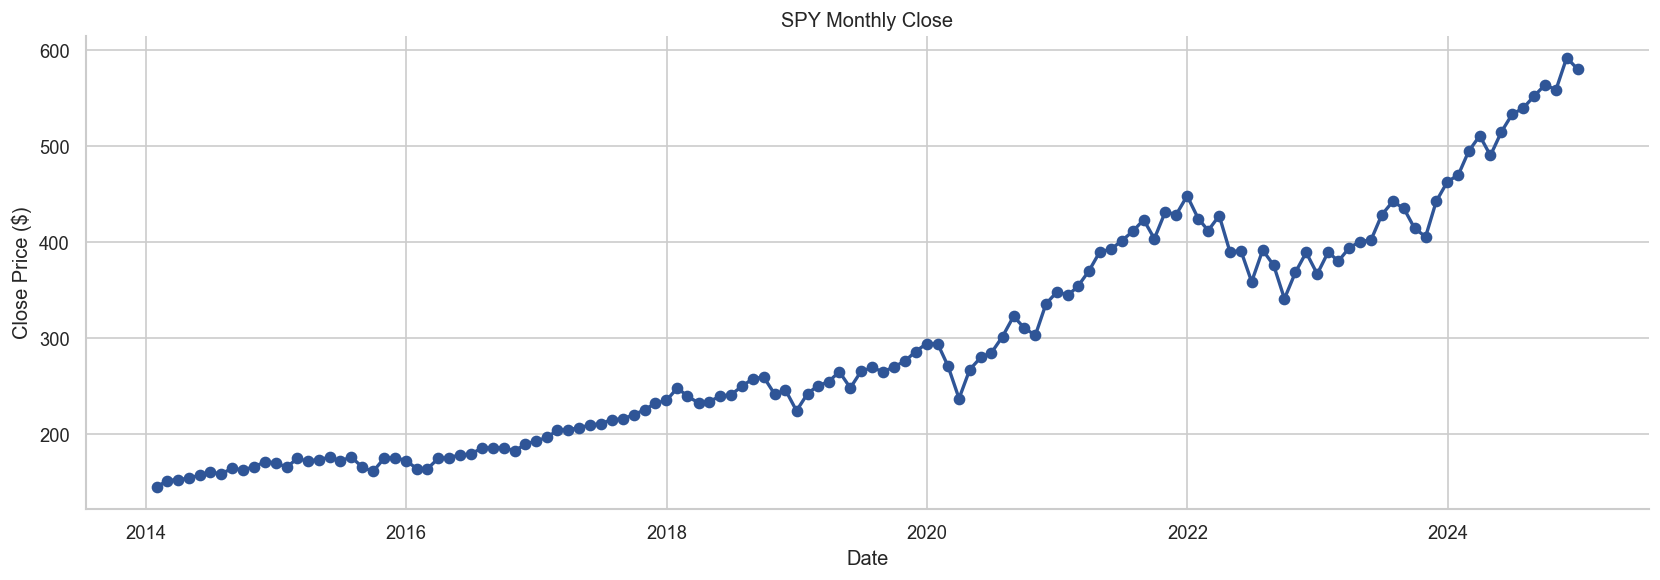

In [362]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

event_colors = {
    "Hike": "#2E7D32",
    "Cut": "#C62828",
    "Other": "#8A8A8A",
    "hike": "#2E7D32",
    "cut": "#C62828",
    "other": "#8A8A8A",
    "hike_window": "#2E7D32",
    "cut_window": "#C62828",
    "Hike_window": "#2E7D32",
    "Cut_window": "#C62828",
}

# Ensure Date is datetime
spy['Date'] = pd.to_datetime(spy['Date'])

# Set index
spy = spy.set_index('Date')

# End-of-month closing price
monthly_price = spy['Close'].resample('M').last()

plt.figure(figsize=(14,5))

plt.plot(monthly_price.index, monthly_price.values, marker='o', linewidth=2, color="#2F5597")

plt.title("SPY Monthly Close")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [363]:
macro_data

,date,Year_x,Month_x,corecpi,corepce,UNRATE
0,2014-01,2014,01,1.033028,1.309380,6.6
1,2014-02,2014,02,1.145138,0.569520,6.7
2,2014-03,2014,03,2.258584,1.793589,6.7
3,2014-04,2014,04,2.290579,2.072982,6.2
4,2014-05,2014,05,2.337905,2.043780,6.3
...,...,...,...,...,...,...
127,2024-08,2024,08,3.462634,2.139300,4.2
128,2024-09,2024,09,3.801552,3.344326,4.1
129,2024-10,2024,10,3.237494,3.615829,4.1
130,2024-11,2024,11,3.528748,1.267071,4.2


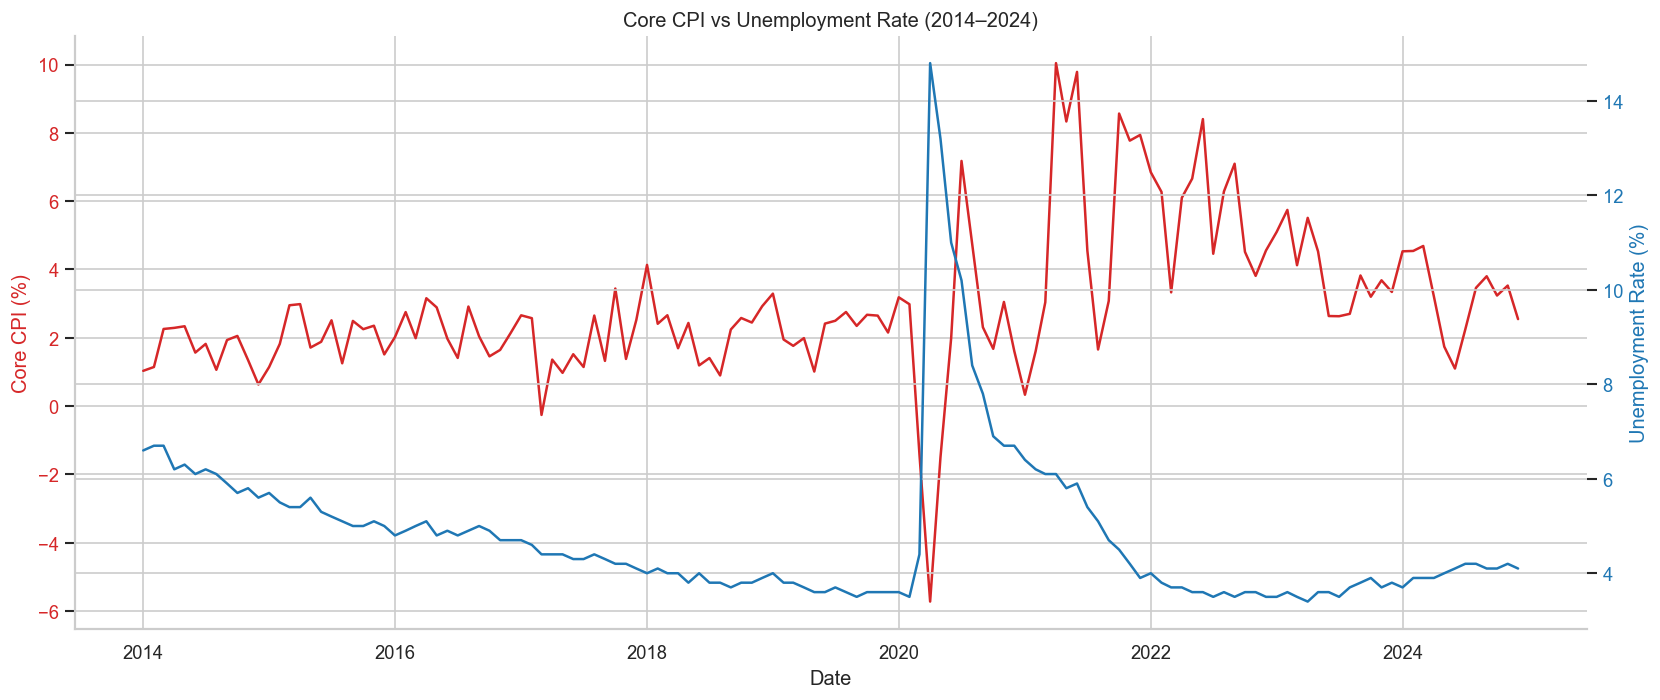

In [364]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ensure date is datetime
macro_data['date'] = pd.to_datetime(macro_data['date'])

plt.figure(figsize=(14,6))

# First axis (left): core CPI
ax1 = plt.gca()
ax1.plot(macro_data['date'], macro_data['corecpi'], label='Core CPI', color='tab:red')
ax1.set_xlabel("Date")
ax1.set_ylabel("Core CPI (%)", color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Second axis (right): unemployment rate
ax2 = ax1.twinx()
ax2.plot(macro_data['date'], macro_data['UNRATE'], label='Unemployment Rate', color='tab:blue')
ax2.set_ylabel("Unemployment Rate (%)", color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title("Core CPI vs Unemployment Rate (2014–2024)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [365]:
stock_rt_df = df.copy()
stock_rt_df = stock_rt_df.drop(columns = ['Open','High','Low','ret'])

#Percentage change in price
stock_rt_df['ret'] = stock_rt_df.groupby('ticker')['Close'].pct_change()

#Merge With market
stock_mkt = (
    market
    .merge(stock_rt_df.assign(Date=pd.to_datetime(stock_rt_df['Date'])),
           on='Date', how='left')
    .sort_values(['ticker', 'Date'])
    .reset_index(drop=True)
)
stock_mkt


,Date,mkt_ret,ticker,sector,Close,Volume,ret
0,2014-01-02,NaN,AAPL,Technology,17.156704,234684800,NaN
1,2014-01-03,-0.000164,AAPL,Technology,16.779840,392467600,-0.021966
2,2014-01-06,-0.002898,AAPL,Technology,16.871340,412610800,0.005453
3,2014-01-07,0.006142,AAPL,Technology,16.750685,317209200,-0.007151
4,2014-01-08,0.000218,AAPL,Technology,16.856762,258529600,0.006333
...,...,...,...,...,...,...,...
166015,2024-12-23,0.005988,ZG,Communication Services,73.379997,334000,-0.005287
166016,2024-12-24,0.011115,ZG,Communication Services,73.800003,200900,0.005724
166017,2024-12-26,0.000067,ZG,Communication Services,73.660004,295400,-0.001897
166018,2024-12-27,-0.010527,ZG,Communication Services,72.739998,248500,-0.012490


In [366]:
stock_fomc = (
    stock_mkt
    .merge(FOMC_rate.assign(Date=pd.to_datetime(FOMC_rate['date'])),
           on='Date', how='left')
    .sort_values(['ticker', 'Date'])
    .reset_index(drop=True)
)
stock_fomc[['Year','Month','Day']] = stock_mkt['Date'].dt.strftime('%Y-%m-%d').str.split('-', expand=True)
macro_data = macro_data.rename(columns={'Year_x':'Year','Month_x':'Month'})
combined_df = stock_fomc.merge(macro_data, on=['Year', 'Month'], how='left')

In [367]:
#final_df = final_df.drop(columns=['date','Year','Month','Day'])
combined_df['is_cut'] = 0
combined_df['is_hike'] = 0
combined_df.loc[combined_df['change_bps']<0,'is_cut'] = 1
combined_df.loc[combined_df['change_bps']>0,'is_hike'] = 1
combined_df['change_bps'] = combined_df['change_bps'].fillna(0)

In [368]:
final_df = combined_df.drop(columns=['year','direction','new_target_range','Target_Low','Target_High','Year','Month','Day'])
sector_dummies = pd.get_dummies(final_df['sector'], prefix='sector')
sector_dummies = sector_dummies.astype(int)

final_df = pd.concat([final_df, sector_dummies], axis=1)
#nvda = final_df[final_df['ticker'] == 'NVDA'].copy()

final_df = final_df.dropna(subset=['mkt_ret','ret'])


In [369]:
final_df.columns

Index(['Date', 'mkt_ret', 'ticker', 'sector', 'Close', 'Volume', 'ret',
       'date_x', 'change_bps', 'date_y', 'corecpi', 'corepce', 'UNRATE',
       'is_cut', 'is_hike', 'sector_Communication Services',
       'sector_Consumer Cyclical', 'sector_Finance', 'sector_Healthcare',
       'sector_Technology', 'sector_Utility'],
      dtype='object')

## Model 1: Baseline Market-Control Return Regression

Estimate each stock return as a function of market return plus hike/cut event-day indicators. This provides a simple first look at directional stock reactions.

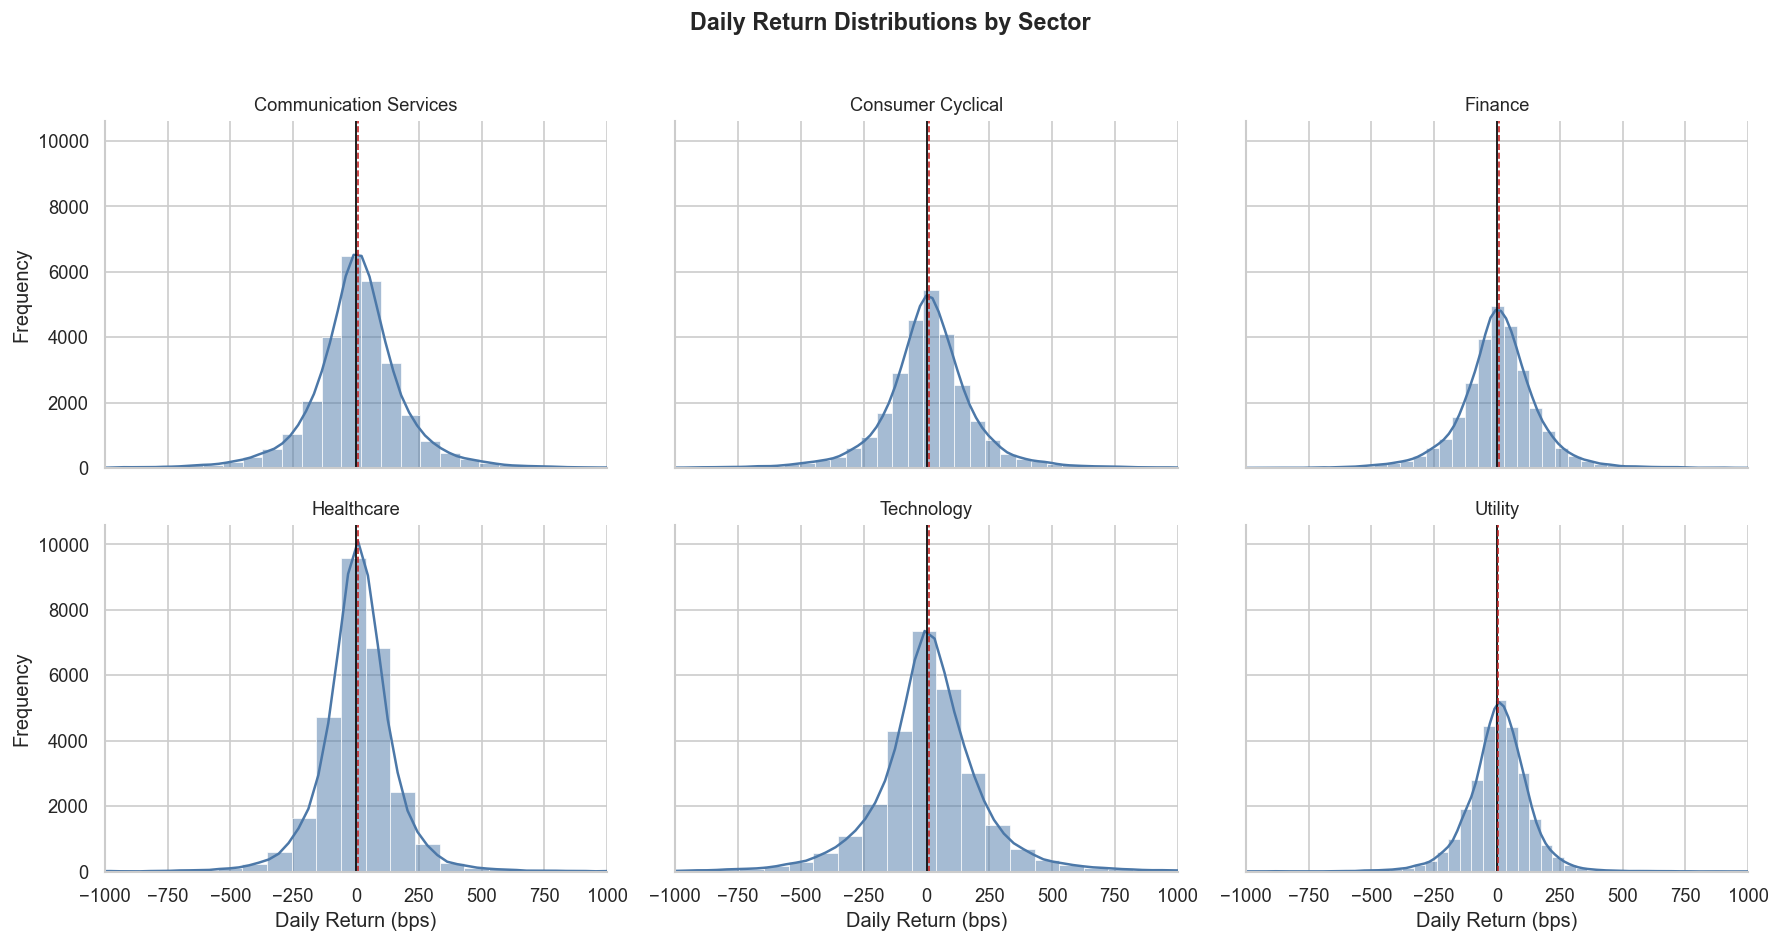

In [370]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# List of sectors (2×3 layout)
sectors = [
    "Communication Services",
    "Consumer Cyclical",
    "Finance",
    "Healthcare",
    "Technology",
    "Utility"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, sec in zip(axes, sectors):
    # Filter returns for this sector
    data = final_df.loc[final_df["sector"] == sec, "ret"].dropna() * 10000

    sns.histplot(
        data,
        bins=80,
        kde=True,
        edgecolor='white',
        linewidth=0.4,
        color="#4C78A8",
        ax=ax
    )

    ax.set_title(sec, fontsize=11)

    # Add zero and mean lines
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(data.mean(), color="#C62828", linestyle="--", linewidth=1)

    # Set X-axis range to [-1000, 1000] bps
    ax.set_xlim(-1000, 1000)

    ax.set_xlabel("Daily Return (bps)")
    ax.set_ylabel("Frequency" if ax in axes[::3] else "")

fig.suptitle("Daily Return Distributions by Sector", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [371]:
market

,Date,mkt_ret
0,2014-01-02,NaN
1,2014-01-03,-0.000164
2,2014-01-06,-0.002898
3,2014-01-07,0.006142
4,2014-01-08,0.000218
...,...,...
2762,2024-12-23,0.005988
2763,2024-12-24,0.011115
2764,2024-12-26,0.000067
2765,2024-12-27,-0.010527


In [372]:
import statsmodels.api as sm
import pandas as pd

results = []

for ticker, g in final_df.groupby('ticker'):

    # Independent variables
    X = g[['mkt_ret', 'is_hike', 'is_cut']]
    X = sm.add_constant(X)

    # Dependent variable
    y = g['ret']

    # Fit model
    model = sm.OLS(y, X, missing='drop').fit()

    # Save results
    results.append({
        'Ticker': ticker,
        'alpha': model.params.get('const'),
        'beta_mkt': model.params.get('mkt_ret'),
        'gamma_hike': model.params.get('is_hike'),
        'gamma_cut': model.params.get('is_cut'),
        'p_hike': model.pvalues.get('is_hike'),
        'p_cut': model.pvalues.get('is_cut'),
        'r2': model.rsquared
    })

results_df = pd.DataFrame(results)
results_df

,Ticker,alpha,beta_mkt,gamma_hike,gamma_cut,p_hike,p_cut,r2
0,AAPL,0.000475,1.192899,-0.001833,0.002319,0.495840,0.584571,0.536878
1,ABBV,0.000366,0.710368,0.001147,-0.007807,0.730484,0.136921,0.212571
2,ABT,0.000106,0.859433,-0.000463,-0.001084,0.852983,0.782897,0.411628
3,AEP,0.000171,0.505023,0.002131,0.004239,0.419905,0.308718,0.176632
4,AMD,0.000916,1.650632,0.004206,0.008223,0.551351,0.459888,0.243176
5,AMGN,0.000039,0.797361,0.002642,0.008970,0.367173,0.052128,0.303256
6,AMZN,0.000393,1.181426,0.002322,0.007839,0.524812,0.173137,0.381098
7,AVGO,0.001002,1.400749,-0.000098,-0.008506,0.980424,0.174904,0.423209
8,AXP,0.000022,1.220562,-0.005440,0.004112,0.072711,0.389395,0.489954
9,BAC,-0.000015,1.240169,-0.002356,-0.009776,0.442060,0.043030,0.492930


## Model 2: Abnormal Return Event Model

Estimate a market model for each stock, compute abnormal returns, and test whether FOMC hike/cut days explain those abnormal returns.

$$
Abnormal Return_{i,t}
= Return_{i,t} - \left( \hat{\alpha}_i + \hat{\beta}_i Market_{m,t} \right)
$$


$$
Abnormal Return_{i,t}
= \gamma_0
+ \gamma_1 \,\text{is\_hike}_t
+ \gamma_2 \,\text{is\_cut}_t
+ u_{i,t}
$$


In [373]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Sort first
final_df = final_df.sort_values(['ticker', 'Date']).copy()

# Initialize AR as float
final_df['AR'] = np.nan

# -------- 1) Market model per (ticker, sector) to get AR --------
for (ticker, sector), g in final_df.groupby(['ticker', 'sector']):
    X = sm.add_constant(g['mkt_ret'])
    y = g['ret']

    mm = sm.OLS(y, X, missing='drop').fit()

    # Abnormal return = actual - predicted
    final_df.loc[g.index, 'AR'] = y - mm.predict(X)

# -------- 2) AR regression on FOMC dummies & change_bps per ticker --------
ar_results = []

for ticker, g in final_df.groupby('ticker'):

    y = g['AR'].astype(float)

    X = g[['is_cut', 'is_hike', 'change_bps']]
    X = sm.add_constant(X)

    model = sm.OLS(y, X, missing='drop').fit()

    ar_results.append({
        'Ticker': ticker,
        'Sector': g['sector'].iloc[0],   # sector from this ticker's group

        # effects
        'gamma_hike':   model.params.get('is_hike',    np.nan),
        'gamma_cut':    model.params.get('is_cut',     np.nan),
        'gamma_change': model.params.get('change_bps', np.nan),

        # p-values
        'p_hike':   model.pvalues.get('is_hike',    np.nan),
        'p_cut':    model.pvalues.get('is_cut',     np.nan),
        'p_change': model.pvalues.get('change_bps', np.nan),

        'r2': model.rsquared
    })

ar_results_df = pd.DataFrame(ar_results)
ar_results_df


,Ticker,Sector,gamma_hike,gamma_cut,gamma_change,p_hike,p_cut,p_change,r2
0,AAPL,Technology,0.005225,-0.005320,-0.000188,2.722417e-01,0.375649,7.258549e-02,0.001444
1,ABBV,Healthcare,-0.014700,0.009375,0.000423,1.245202e-02,0.206386,1.100136e-03,0.004692
2,ABT,Healthcare,-0.001632,0.000189,0.000031,7.116998e-01,0.972884,7.477206e-01,0.000077
3,AEP,Utility,-0.000825,0.007413,0.000078,8.597926e-01,0.208789,4.455708e-01,0.000814
4,AMD,Technology,0.025009,-0.014370,-0.000555,4.513268e-02,0.361538,4.325692e-02,0.001800
5,AMGN,Healthcare,0.004375,0.007046,-0.000047,3.985683e-01,0.281338,6.816227e-01,0.001705
6,AMZN,Consumer Cyclical,0.022199,-0.013737,-0.000531,5.753454e-04,0.091093,1.859771e-04,0.005852
7,AVGO,Technology,-0.004308,-0.003918,0.000113,5.403468e-01,0.658982,4.671966e-01,0.000857
8,AXP,Finance,0.000213,-0.001985,-0.000150,9.682797e-01,0.769095,2.024194e-01,0.002026
9,BAC,Finance,-0.009296,-0.002210,0.000186,8.630604e-02,0.746507,1.196532e-01,0.002557


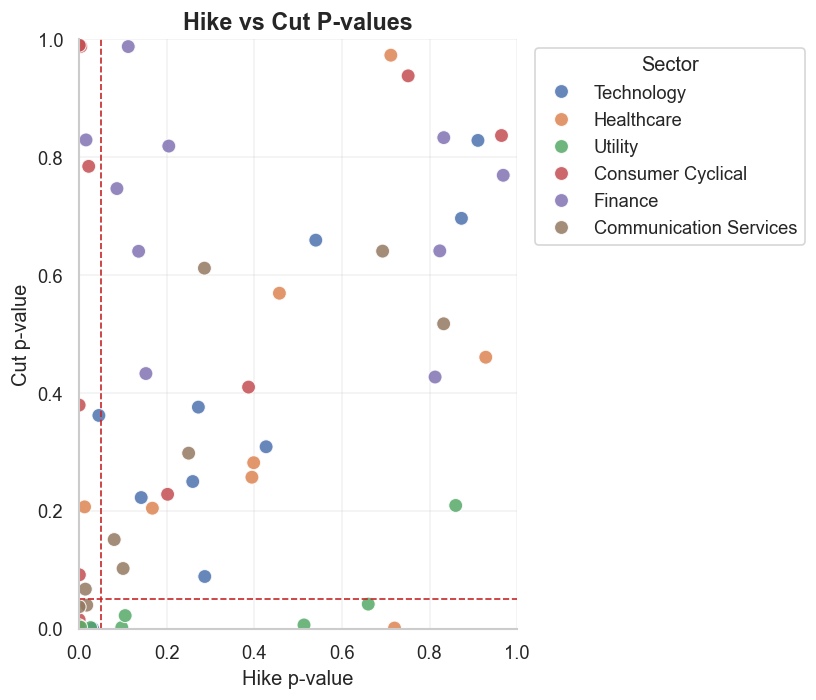

In [374]:
import matplotlib.pyplot as plt
import seaborn as sns

def p_value_plot(df, threshold=0.05):
    fig, ax = plt.subplots(figsize=(7, 6))

    if 'Sector' in df.columns:
        sns.scatterplot(
            data=df,
            x='p_hike',
            y='p_cut',
            hue='Sector',
            s=70,
            alpha=0.85,
            ax=ax
        )
        ax.legend(title='Sector', bbox_to_anchor=(1.02, 1), loc='upper left')
    else:
        ax.scatter(df['p_hike'], df['p_cut'], s=70, alpha=0.85, color="#4C78A8")

    ax.axvline(threshold, color='#C62828', linestyle='--', linewidth=1)
    ax.axhline(threshold, color='#C62828', linestyle='--', linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel('Hike p-value', fontsize=12)
    ax.set_ylabel('Cut p-value', fontsize=12)
    ax.set_title('Hike vs Cut P-values', fontsize=14, fontweight='bold')

    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

p_value_plot(ar_results_df)

In [375]:
df = ar_results_df.copy()

df['sig_hike'] = df['p_hike'] < 0.2
df['sig_cut']  = df['p_cut']  < 0.2

def label_row(row):
    if row['sig_hike'] and row['sig_cut']:
        return 'Both'
    elif row['sig_hike']:
        return 'Hike Only'
    elif row['sig_cut']:
        return 'Cut Only'
    else:
        return 'Not Significant'

df['sig_category'] = df.apply(label_row, axis=1)

sector_counts = (
    df.groupby(['Sector', 'sig_category'])['Ticker']
      .count()
      .reset_index()
      .pivot(index='Sector', columns='sig_category', values='Ticker')
      .fillna(0)
)

sector_counts


sig_category,Both,Cut Only,Hike Only,Not Significant
Sector,,,,
Communication Services,6.0,0.0,0.0,4.0
Consumer Cyclical,2.0,0.0,4.0,4.0
Finance,0.0,0.0,5.0,5.0
Healthcare,2.0,1.0,2.0,5.0
Technology,1.0,1.0,2.0,6.0
Utility,7.0,2.0,0.0,1.0


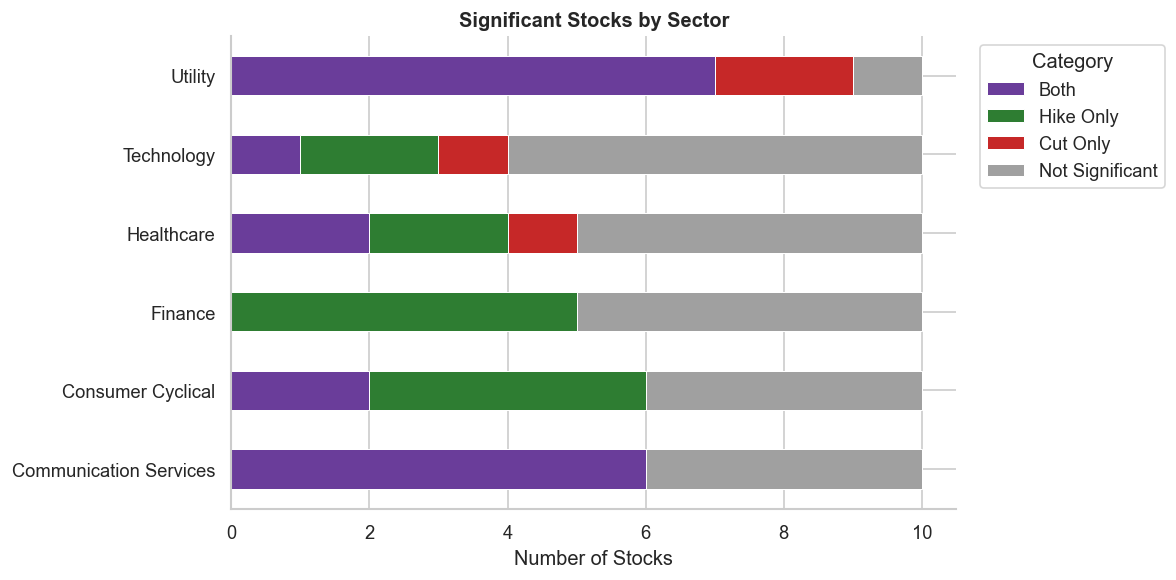

In [376]:
import matplotlib.pyplot as plt

category_colors = {
    'Both': '#6A3D9A',
    'Hike Only': '#2E7D32',
    'Cut Only': '#C62828',
    'Not Significant': '#A0A0A0'
}
ordered_cols = [col for col in category_colors if col in sector_counts.columns]

ax = sector_counts[ordered_cols].plot(
    kind='barh',
    stacked=True,
    figsize=(10, 5),
    color=[category_colors[col] for col in ordered_cols],
    edgecolor='white',
    linewidth=0.6
)

ax.set_title("Significant Stocks by Sector", fontweight='bold')
ax.set_xlabel("Number of Stocks")
ax.set_ylabel("")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


<div style="background:#fff7d6; border-left:6px solid #d89b00; padding:12px 14px; border-radius:6px; margin:10px 0;">
<b>Key takeaway:</b> FOMC sensitivity is not evenly distributed across sectors. Using the exploratory p &lt; 0.20 cutoff, Utility stocks show the broadest abnormal-return response, with 8 of 10 classified as significant for both hike and cut effects. Communication Services and Technology also show several sensitive names, while Finance is mostly not significant in this abnormal-return screen.
</div>

/var/folders/fj/pxz8d_45589622lsp3n_9t4h0000gn/T/ipykernel_62639/2199398893.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


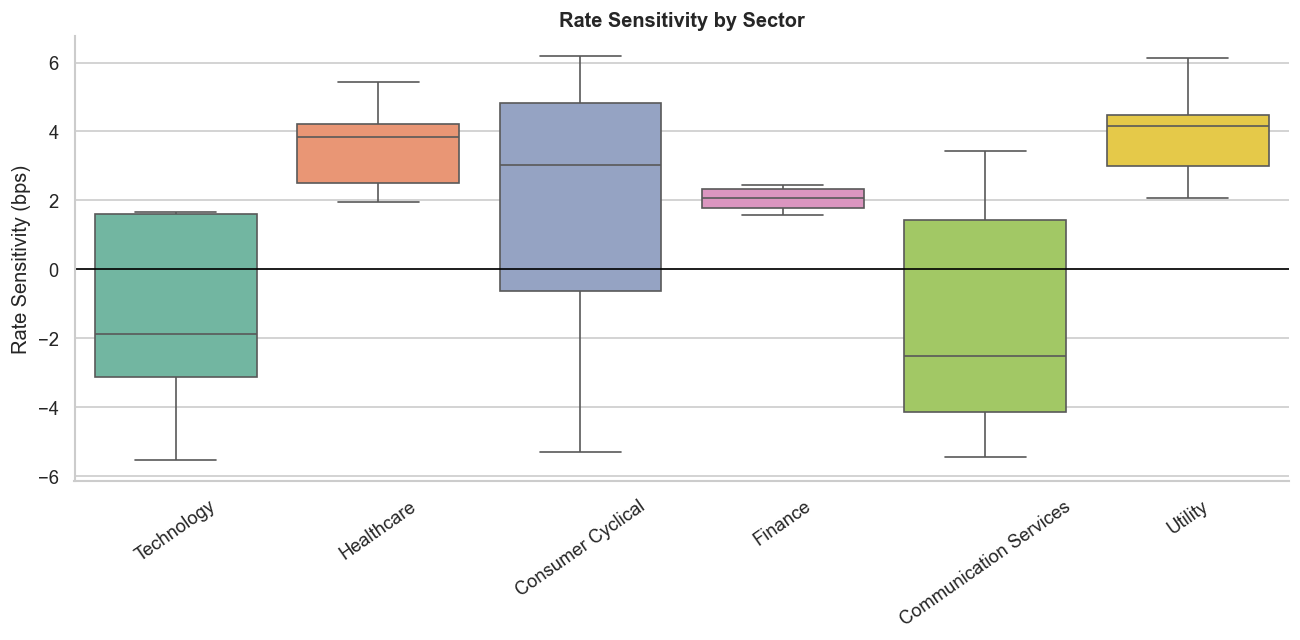

In [377]:
import seaborn as sns
import matplotlib.pyplot as plt

def gamma_boxplot(df):
    df_bps = df.copy()
    df_bps = df_bps[df_bps['p_change']<0.2]
    df_bps['gamma_change_bps'] = df_bps['gamma_change'] * 10000   # convert to bps

    fig, ax = plt.subplots(figsize=(11, 5.5))

    sns.boxplot(
        data=df_bps,
        x='Sector',
        y='gamma_change_bps',
        palette='Set2',
        linewidth=1,
        ax=ax
    )

    ax.set_title("Rate Sensitivity by Sector", fontweight='bold')
    ax.set_ylabel("Rate Sensitivity (bps)")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=35)

    ax.axhline(0, color='black', linewidth=1)   # helpful reference line

    plt.tight_layout()
    plt.show()

gamma_boxplot(ar_results_df)


## Part 2: Event-Window and Sector Visualizations

Visualize how average returns and sector reactions change around FOMC events, including presentation-ready summaries for interview discussion.

In [378]:
events = FOMC_rate[['date','direction']]
events = events.rename(columns={'direction':'event_type','date':'Date'})
events['Date'] = pd.to_datetime(events['Date'])

import pandas as pd

def compute_avg_returns_event_window(
    final_df,
    events,
    pre_days=10,
    post_days=10,
    date_col='Date',
    ret_col='ret',
    group_cols=None,
):
    """
    Compute average returns within a pre/post window around events
    vs all other days.

    Parameters
    ----------
    final_df : pd.DataFrame
        Main data with returns (must contain `date_col` and `ret_col`).
    events : pd.DataFrame
        Event dates and types (must contain `date_col` and 'event_type').
    pre_days : int
        Number of days before the event to include (e.g. 10 for -10).
    post_days : int
        Number of days after the event to include (e.g. 10 for +10).
    date_col : str
        Name of the date column in both DataFrames (default 'Date').
    ret_col : str
        Name of the return column in `final_df` (default 'ret').
    group_cols : list or None
        Extra columns to group by (e.g. ['sector']). If None, only day_group.

    Returns
    -------
    pd.DataFrame
        Average returns by group_cols + day_group, where day_group is:
        - '{event_type}_window' (e.g. 'hike_window', 'cut_window')
        - 'other' (not in any event window)
    """

    df = final_df.copy()
    ev = events.copy()

    # Ensure datetime
    df[date_col] = pd.to_datetime(df[date_col])
    ev[date_col] = pd.to_datetime(ev[date_col])

    # Build window labels: for each event, mark all dates in [T-pre, T+post]
    window_list = []

    for _, row in ev.iterrows():
        event_date = row[date_col]
        etype = row['event_type']

        start = event_date - pd.Timedelta(days=pre_days)
        end = event_date + pd.Timedelta(days=post_days)

        tmp = df.loc[(df[date_col] >= start) & (df[date_col] <= end), [date_col]].drop_duplicates()
        tmp['day_group'] = f'{etype}_window'   # e.g. 'hike_window', 'cut_window'
        window_list.append(tmp)

    if window_list:
        window_df = pd.concat(window_list, ignore_index=True)
        # If a date appears in multiple windows, keep the last label (you can change this logic)
        window_df = window_df.drop_duplicates(subset=[date_col], keep='last')
    else:
        window_df = pd.DataFrame(columns=[date_col, 'day_group'])

    # Merge window labels back to main df
    df = df.merge(window_df, on=date_col, how='left')
    df['day_group'] = df['day_group'].fillna('other')

    # Build group-by columns
    if group_cols is None:
        gb_cols = ['day_group']
    else:
        gb_cols = list(group_cols) + ['day_group']

    result = (
        df.groupby(gb_cols)[ret_col]
          .mean()
          .reset_index()
          .rename(columns={ret_col: 'avg_return'})
    )

    return result


In [379]:
# Define 10-day bins from -60 to +60
bins = [(i, i+10) for i in range(-60, 60, 10)]
labels = [f"{low} to {high}" for low, high in bins]

def build_tau_panel(final_df, events, tau_min=-60, tau_max=60):
    df = final_df.copy()
    ev = events.copy()

    df['Date'] = pd.to_datetime(df['Date'])
    ev['Date'] = pd.to_datetime(ev['Date'])

    rows = []

    for _, e in ev.iterrows():
        event_date = e['Date']
        etype = e['event_type']

        start = event_date + pd.Timedelta(days=tau_min)
        end   = event_date + pd.Timedelta(days=tau_max)

        mask = (df['Date'] >= start) & (df['Date'] <= end)
        tmp = df.loc[mask, ['Date', 'sector', 'ret']].copy()

        if tmp.empty:
            continue

        tmp['tau'] = (tmp['Date'] - event_date).dt.days
        tmp['event_type'] = etype
        rows.append(tmp)

    if not rows:
        return pd.DataFrame(columns=['sector','event_type','tau','ret'])

    return pd.concat(rows, ignore_index=True)


tau_panel = build_tau_panel(final_df, events, -60, 60)

def assign_bin(tau):
    for low, high in bins:
        if low <= tau < high:
            return f"{low} to {high}"
    return None

tau_panel['bin'] = tau_panel['tau'].apply(assign_bin)

bin_avg = (
    tau_panel.groupby(['sector','event_type','bin'])['ret']
             .mean()
             .reset_index()
)

bin_avg['ret_bps'] = bin_avg['ret'] * 10000

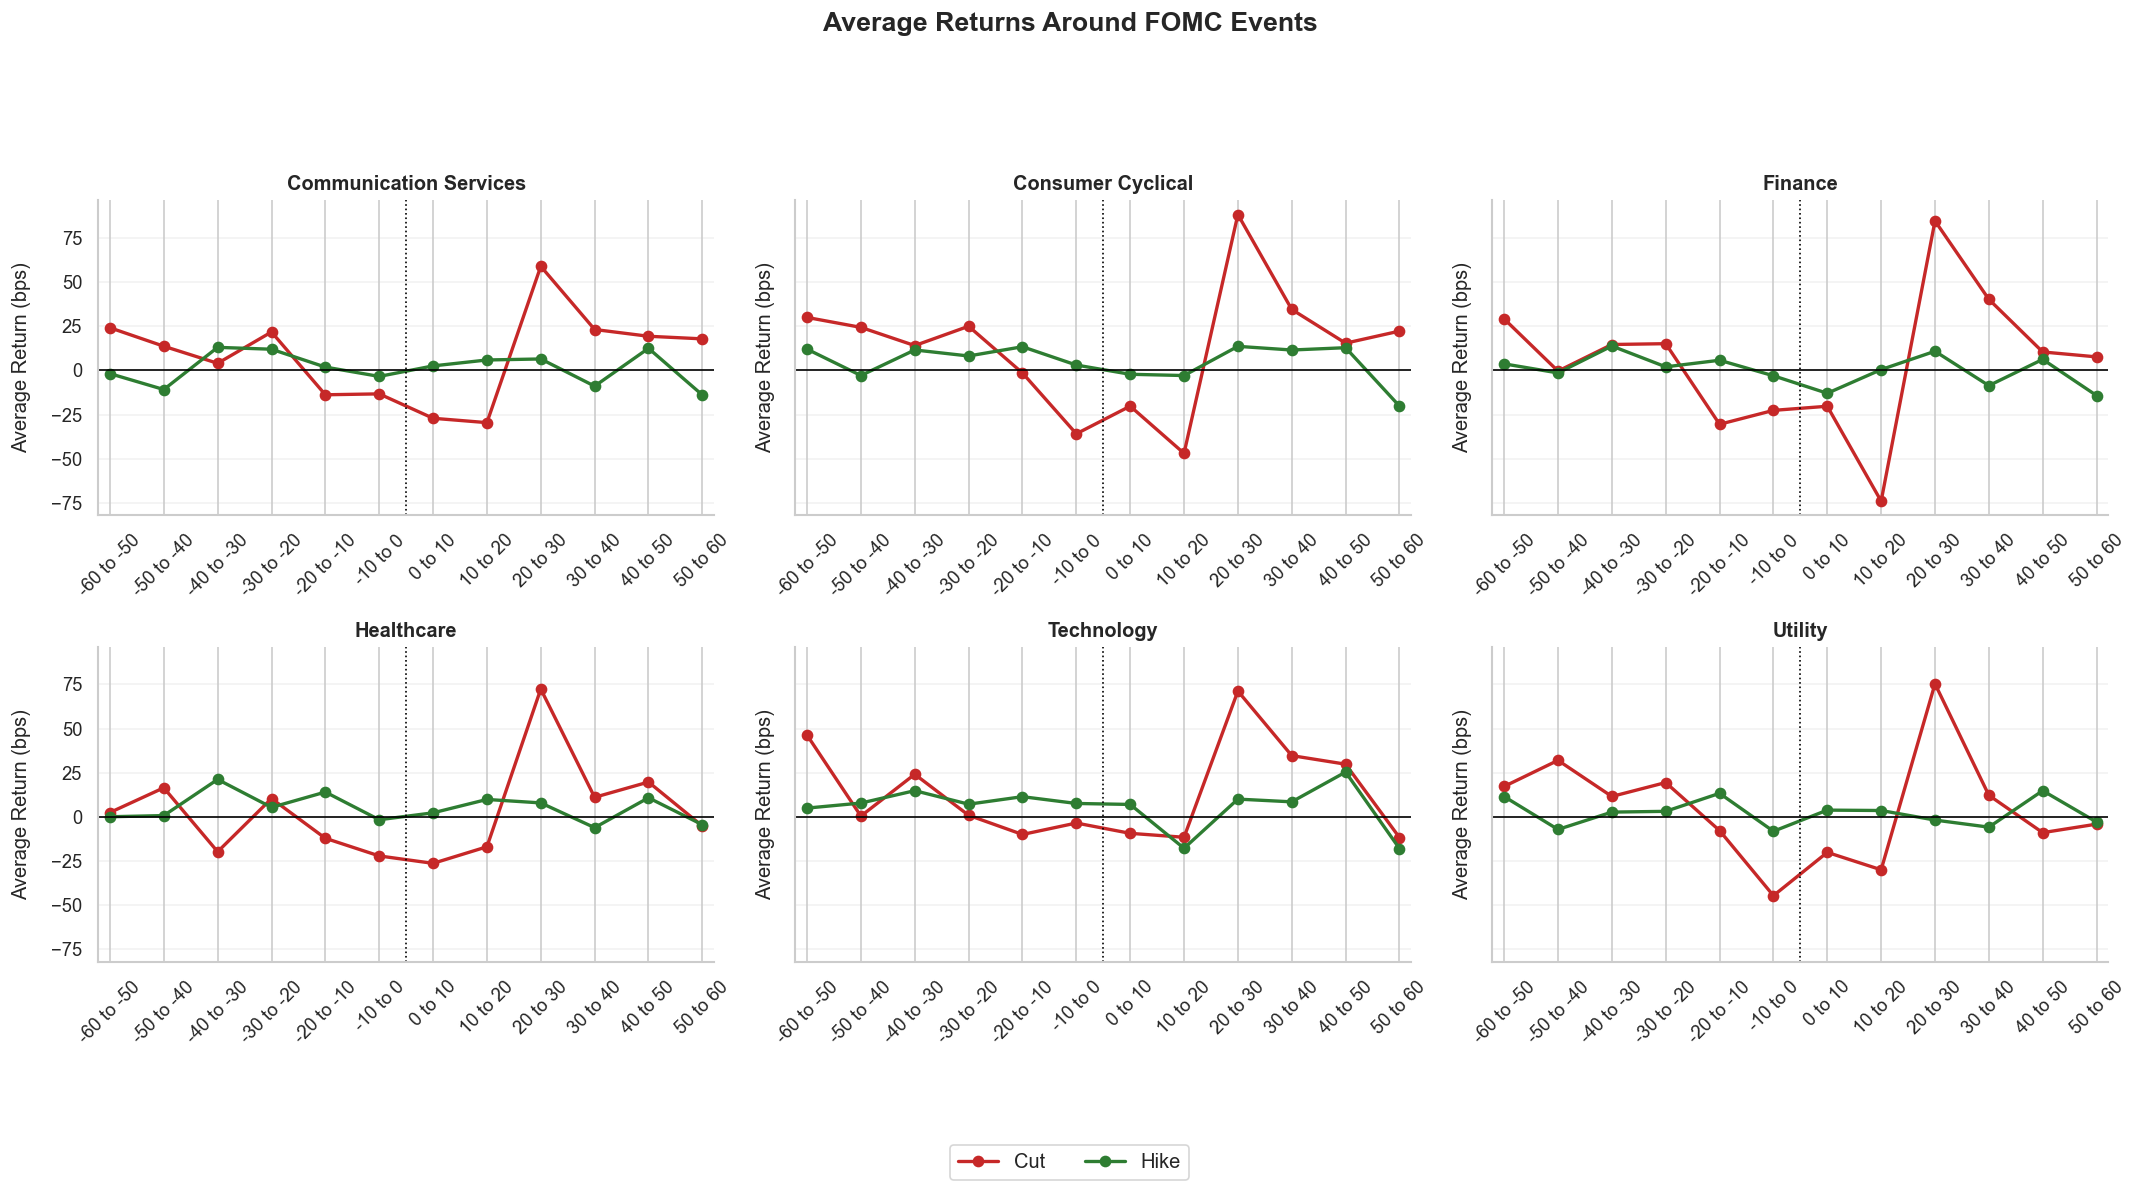

In [380]:
import numpy as np
import matplotlib.pyplot as plt

# define sectors and event types from the actual data
sectors = sorted(bin_avg['sector'].unique())
event_types = sorted(bin_avg['event_type'].unique())  # e.g. ['hike','cut'] or ['Hike','Cut']

# x and labels already defined from your bins
# bins = [(i, i+10) for i in range(-60, 60, 10)]
# labels = [f"{low} to {high}" for low, high in bins]
x = np.arange(len(labels))

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for ax, sector in zip(axes, sectors):
    sub = bin_avg[bin_avg['sector'] == sector]

    if sub.empty:
        ax.set_visible(False)
        continue

    for etype in event_types:
        tmp = (
            sub[sub['event_type'] == etype]
            .set_index('bin')
            .reindex(labels)        # ensure all bins present in this order
        )

        # only plot if at least some data exist
        if tmp['ret_bps'].notna().any():
            ax.plot(
                x,
                tmp['ret_bps'].to_numpy(),
                marker='o',
                linewidth=2,
                color=event_colors.get(str(etype), None),
                label=str(etype).capitalize()
            )

    ax.set_title(str(sector), fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(5.5, color='black', linestyle=':', linewidth=1)
    ax.grid(True, axis='y', alpha=0.25)
    ax.margins(x=0.02)
    ax.set_ylabel('Average Return (bps)', labelpad=12)

# hide unused axes if you have fewer than 6 sectors
for ax in axes[len(sectors):]:
    ax.set_visible(False)

fig.suptitle("Average Returns Around FOMC Events",
             fontsize=16, fontweight='bold')

plt.subplots_adjust(left=0.12, top=0.92)

# shared legend from all axes
handles, labels_leg = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels_leg:
            handles.append(hh)
            labels_leg.append(ll)

fig.legend(handles, labels_leg, loc='lower center', ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0.1, 1, 0.9])
plt.show()


## Part 3: Interview-Ready Visual Storytelling

A compact set of charts designed to communicate the main sector and event-day patterns quickly: event timeline, sector heatmap, stock leaderboard, and policy sensitivity map.

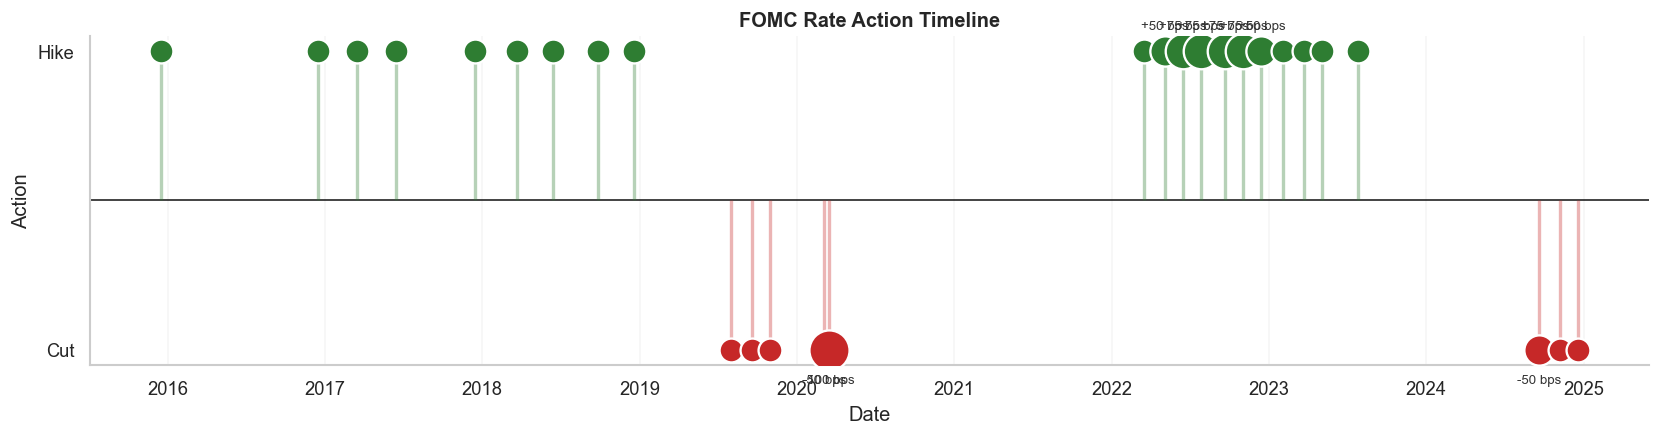

In [381]:
import matplotlib.pyplot as plt
import pandas as pd

event_story = events.merge(
    FOMC_rate.assign(Date=pd.to_datetime(FOMC_rate['date']))[['Date', 'change_bps']],
    on='Date',
    how='left'
)
event_story['event_type'] = event_story['event_type'].astype(str)
event_story['y'] = event_story['event_type'].map({'Hike': 1, 'Cut': -1}).fillna(0)
event_story['size'] = event_story['change_bps'].abs().fillna(25) * 5 + 80

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.axhline(0, color='#222222', linewidth=1)

for _, row in event_story.iterrows():
    color = event_colors.get(row['event_type'], '#8A8A8A')
    ax.vlines(row['Date'], 0, row['y'], color=color, alpha=0.35, linewidth=2)
    ax.scatter(row['Date'], row['y'], s=row['size'], color=color, edgecolor='white', linewidth=1.4, zorder=3)

for _, row in event_story.loc[event_story['change_bps'].abs() >= 50].iterrows():
    ax.annotate(
        f"{int(row['change_bps']):+d} bps",
        xy=(row['Date'], row['y']),
        xytext=(0, 13 if row['y'] > 0 else -20),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color='#333333'
    )

ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['Cut', '', 'Hike'])
ax.set_title('FOMC Rate Action Timeline', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Action')
ax.grid(True, axis='x', alpha=0.18)
ax.grid(False, axis='y')
plt.tight_layout()
plt.show()


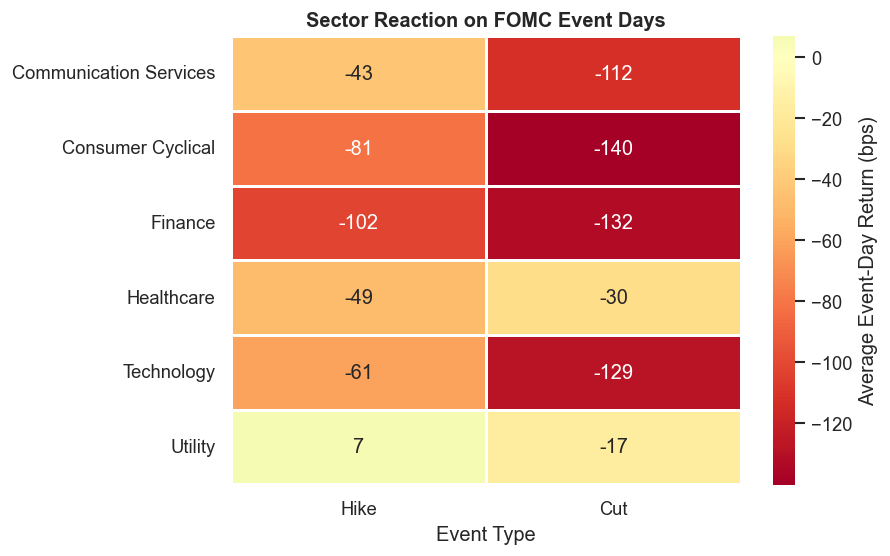

In [382]:
import seaborn as sns
import matplotlib.pyplot as plt

event_day_df = final_df.loc[final_df['is_hike'].eq(1) | final_df['is_cut'].eq(1)].copy()
event_day_df['event_type'] = event_day_df['is_hike'].map({1: 'Hike', 0: 'Cut'})
event_day_df['ret_bps'] = event_day_df['ret'] * 10000

sector_event_heat = (
    event_day_df
    .groupby(['sector', 'event_type'])['ret_bps']
    .mean()
    .unstack('event_type')
    .reindex(columns=['Hike', 'Cut'])
)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
sns.heatmap(
    sector_event_heat,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'Average Event-Day Return (bps)'},
    ax=ax
)
ax.set_title('Sector Reaction on FOMC Event Days', fontweight='bold')
ax.set_xlabel('Event Type')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


<div style="background:#eaf4ff; border-left:6px solid #2f5597; padding:12px 14px; border-radius:6px; margin:10px 0;">
<b>Event-day return takeaway:</b> Average FOMC event-day returns are mostly negative across sectors. Cut days are especially negative for Consumer Cyclical, Finance, Technology, and Communication Services. Utilities look comparatively defensive, with small losses on cut days and slightly positive average returns on hike days.
</div>

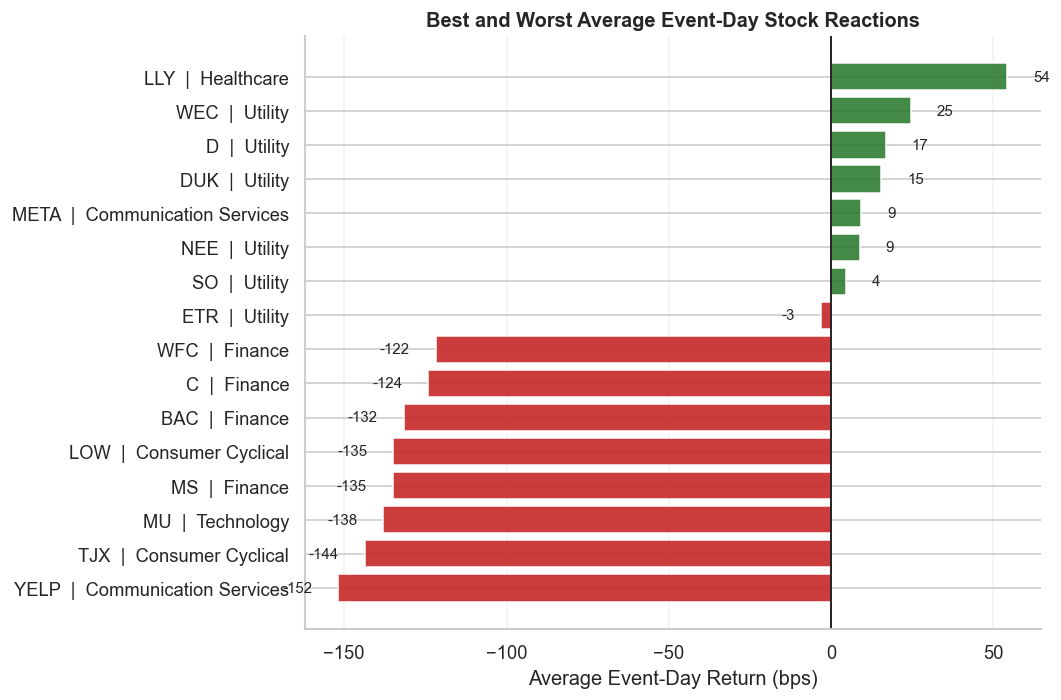

In [383]:
import matplotlib.pyplot as plt
import pandas as pd

ticker_event_rank = (
    event_day_df
    .groupby(['ticker', 'sector'])['ret_bps']
    .mean()
    .reset_index()
    .sort_values('ret_bps')
)

leaderboard = pd.concat([ticker_event_rank.head(8), ticker_event_rank.tail(8)])
leaderboard['label'] = leaderboard['ticker'] + '  |  ' + leaderboard['sector']
bar_colors = leaderboard['ret_bps'].map(lambda x: '#2E7D32' if x >= 0 else '#C62828')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(leaderboard['label'], leaderboard['ret_bps'], color=bar_colors, alpha=0.9)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Best and Worst Average Event-Day Stock Reactions', fontweight='bold')
ax.set_xlabel('Average Event-Day Return (bps)')
ax.set_ylabel('')
ax.grid(True, axis='x', alpha=0.25)

for y, value in enumerate(leaderboard['ret_bps']):
    ax.text(
        value + (8 if value >= 0 else -8),
        y,
        f'{value:.0f}',
        va='center',
        ha='left' if value >= 0 else 'right',
        fontsize=9
    )

plt.tight_layout()
plt.show()


<div style="background:#f3edff; border-left:6px solid #6a3d9a; padding:12px 14px; border-radius:6px; margin:10px 0;">
<b>Stock-level takeaway:</b> The leaderboard shows that the sector story is driven by large differences across individual stocks. This is useful in an interview because it shows you checked both aggregate sector patterns and individual-name dispersion rather than relying only on averages.
</div>

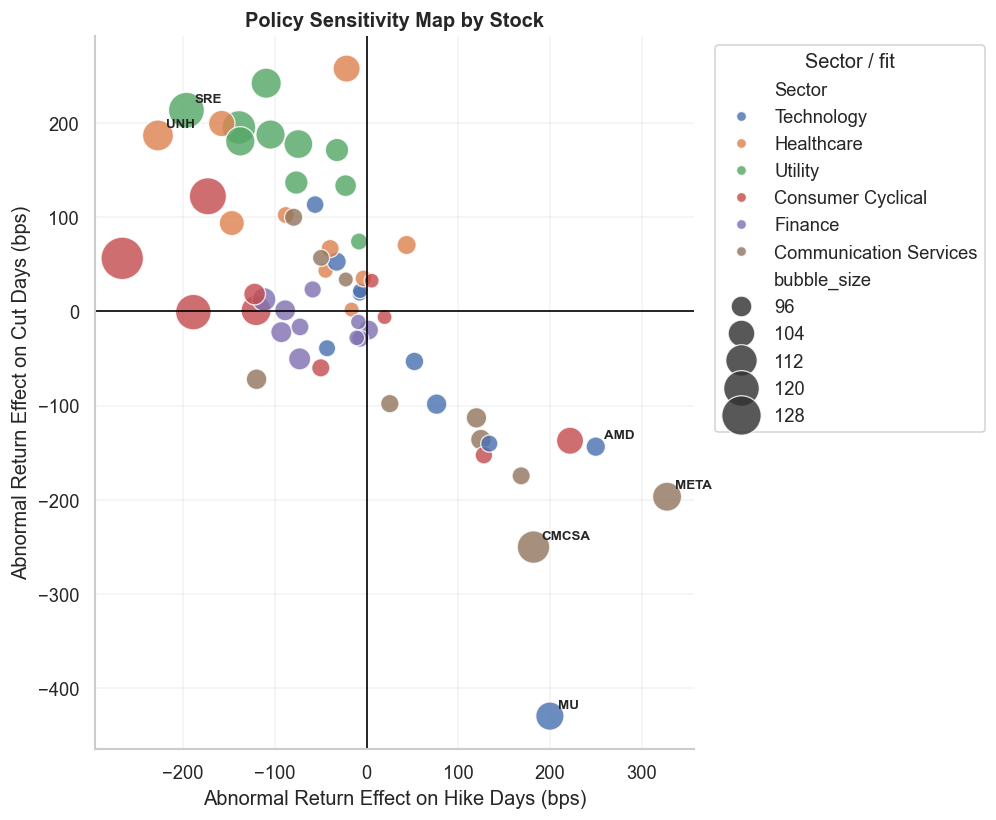

In [384]:
import seaborn as sns
import matplotlib.pyplot as plt

quadrant_df = ar_results_df.copy()
quadrant_df['hike_effect_bps'] = quadrant_df['gamma_hike'] * 10000
quadrant_df['cut_effect_bps'] = quadrant_df['gamma_cut'] * 10000
quadrant_df['bubble_size'] = (quadrant_df['r2'].fillna(0).clip(lower=0) * 2500) + 90

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.scatterplot(
    data=quadrant_df,
    x='hike_effect_bps',
    y='cut_effect_bps',
    hue='Sector',
    size='bubble_size',
    sizes=(80, 650),
    alpha=0.82,
    edgecolor='white',
    linewidth=0.8,
    ax=ax,
    legend='brief'
)
ax.axvline(0, color='black', linewidth=1)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Policy Sensitivity Map by Stock', fontweight='bold')
ax.set_xlabel('Abnormal Return Effect on Hike Days (bps)')
ax.set_ylabel('Abnormal Return Effect on Cut Days (bps)')
ax.grid(True, alpha=0.22)

label_points = quadrant_df.assign(score=quadrant_df['hike_effect_bps'].abs() + quadrant_df['cut_effect_bps'].abs()).nlargest(6, 'score')
for _, row in label_points.iterrows():
    ax.annotate(
        row['Ticker'],
        xy=(row['hike_effect_bps'], row['cut_effect_bps']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        weight='bold'
    )

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Sector / fit')
plt.tight_layout()
plt.show()


## Model 3: Volatility Regression Using Squared Returns

Use squared daily returns as a volatility proxy and test whether hike days, cut days, and rate-change magnitude are associated with higher stock-level volatility.

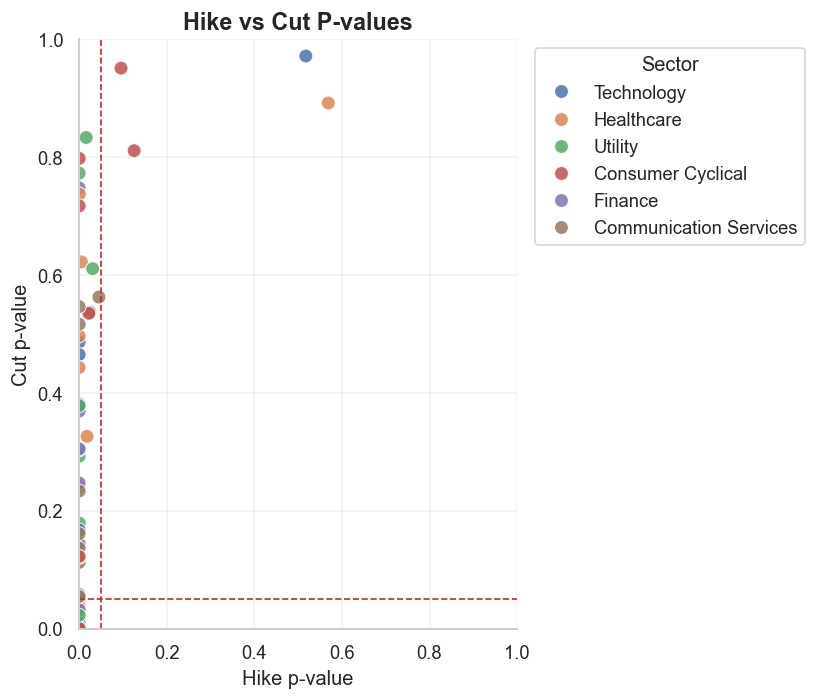

In [385]:
import numpy as np
import statsmodels.api as sm

# Squared returns as volatility proxy
final_df['ret_sq'] = final_df['ret']**2   # CURRENT (in decimal squared units)

vol_results = []

for ticker, g in final_df.groupby('ticker'):
    g = g.dropna(subset=['ret_sq', 'is_hike', 'is_cut', 'change_bps'])
    if g.empty:
        continue

    y = g['ret_sq'].astype(float)
    X = g[['is_hike', 'is_cut', 'change_bps']]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    vol_results.append({
        'Ticker': ticker,
        'Sector': g['sector'].iloc[0],

        'gamma_hike':   model.params.get('is_hike', np.nan),
        'gamma_cut':    model.params.get('is_cut', np.nan),
        'gamma_change': model.params.get('change_bps', np.nan),

        'p_hike':   model.pvalues.get('is_hike', np.nan),
        'p_cut':    model.pvalues.get('is_cut', np.nan),
        'p_change': model.pvalues.get('change_bps', np.nan),

        'r2': model.rsquared
    })

vol_results_df = pd.DataFrame(vol_results)
p_value_plot(vol_results_df)


In [386]:
stock_rt_df

,Date,ticker,sector,Close,Volume,ret
0,2014-01-02,AAPL,Technology,17.156704,234684800,NaN
1,2014-01-03,AAPL,Technology,16.779840,392467600,-0.021966
2,2014-01-06,AAPL,Technology,16.871340,412610800,0.005453
3,2014-01-07,AAPL,Technology,16.750685,317209200,-0.007151
4,2014-01-08,AAPL,Technology,16.856762,258529600,0.006333
...,...,...,...,...,...,...
166015,2024-12-23,DHR,Healthcare,227.778458,2798800,0.002669
166016,2024-12-24,DHR,Healthcare,229.358871,988300,0.006938
166017,2024-12-26,DHR,Healthcare,229.885696,1512400,0.002297
166018,2024-12-27,DHR,Healthcare,229.975250,2130400,0.000390


/var/folders/fj/pxz8d_45589622lsp3n_9t4h0000gn/T/ipykernel_62639/2199398893.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


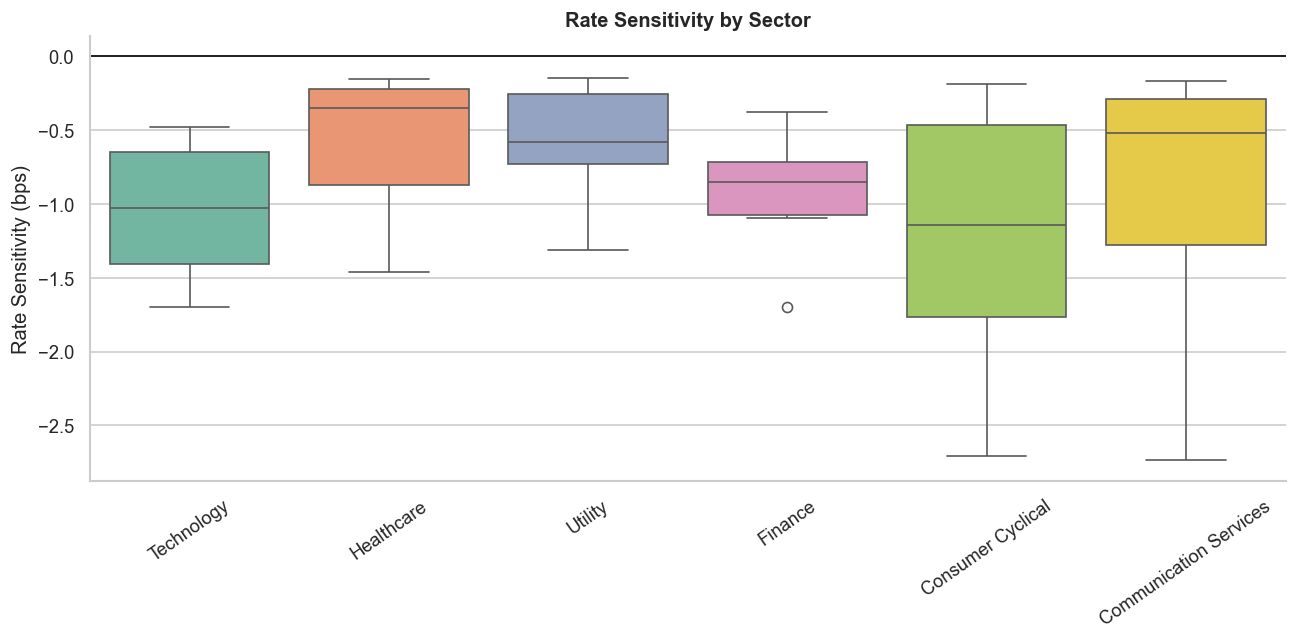

In [387]:
gamma_boxplot(vol_results_df)

In [388]:
import pandas as pd

# 0-day window (event day only)
vol_0 = compute_avg_returns_event_window(
    final_df,
    events,
    pre_days=0,
    post_days=0,
    date_col='Date',
    ret_col='ret_sq',
    group_cols=None
).rename(columns={'avg_return': 'avg_vol'})
vol_0['window'] = '0'

# ±5-day window
vol_5 = compute_avg_returns_event_window(
    final_df,
    events,
    pre_days=5,
    post_days=5,
    date_col='Date',
    ret_col='ret_sq',
    group_cols=None
).rename(columns={'avg_return': 'avg_vol'})
vol_5['window'] = '±5'

# ±10-day window
vol_10 = compute_avg_returns_event_window(
    final_df,
    events,
    pre_days=10,
    post_days=10,
    date_col='Date',
    ret_col='ret_sq',
    group_cols=None
).rename(columns={'avg_return': 'avg_vol'})
vol_10['window'] = '±10'

# ±30-day window
vol_30 = compute_avg_returns_event_window(
    final_df,
    events,
    pre_days=30,
    post_days=30,
    date_col='Date',
    ret_col='ret_sq',
    group_cols=None
).rename(columns={'avg_return': 'avg_vol'})
vol_30['window'] = '±30'

# Combine everything
vol_all = pd.concat([vol_0, vol_5, vol_10, vol_30], ignore_index=True)

# from variance (avg_vol) to std dev in basis points
vol_all['avg_vol_bps'] = np.sqrt(vol_all['avg_vol']) * 10000


$$
\mathrm{avgVol\_bps} = 10000 \,\sqrt{\mathrm{avgVol}}
$$


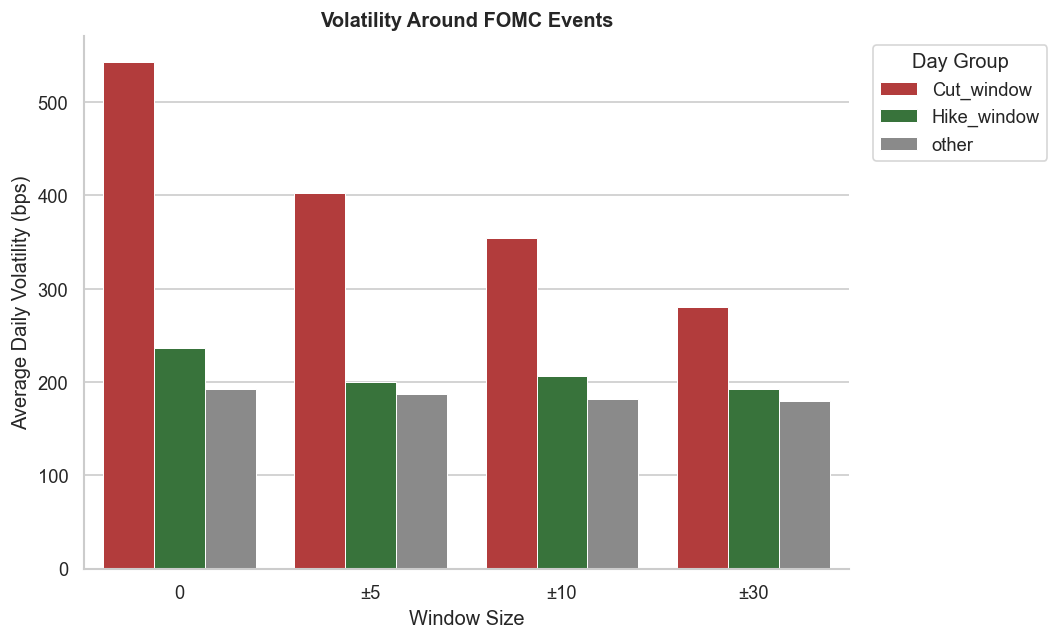

In [389]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Make a copy and create the bps volatility column
vol_all = vol_all.copy()
vol_all['avg_vol_bps'] = np.sqrt(vol_all['avg_vol'].astype(float)) * 10000  # std dev in bps

# 2) Barplot
fig, ax = plt.subplots(figsize=(9, 5.5))

sns.barplot(
    data=vol_all,
    x='window',
    y='avg_vol_bps',
    hue='day_group',              # 'cut_window', 'hike_window', 'other'
    order=['0', '±5', '±10', '±30'],   # only if all these exist; otherwise you can drop 'order='
    palette=event_colors,
    edgecolor='white',
    linewidth=0.6,
    ax=ax
)

ax.set_xlabel("Window Size")
ax.set_ylabel("Average Daily Volatility (bps)")
ax.set_title("Volatility Around FOMC Events", fontweight='bold')
ax.legend(title="Day Group", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


<div style="background:#ffecec; border-left:6px solid #c62828; padding:12px 14px; border-radius:6px; margin:10px 0;">
<b>Volatility takeaway:</b> This is the clearest support for the main research question. Average daily volatility is about 192 bps on non-event days, about 236 bps on hike days, and about 544 bps on cut days. The cut-day spike is much larger, consistent with cuts often occurring in stressed macro environments.
</div>

## Model 4: GARCH(1,1) Volatility Modeling

Model volatility persistence over time and compare conditional volatility around FOMC events. This adds time-series structure to the volatility analysis.

$$
\begin{aligned}
r_t
&= \mu
+ \beta_{\text{hike}}\,\text{is\_hike}_t
+ \beta_{\text{cut}}\,\text{is\_cut}_t
+ \beta_{\Delta r}\,\Delta\text{rate}_t
+ \varepsilon_t,
\qquad \varepsilon_t = z_t \sqrt{h_t},
\\[6pt]
h_t
&= \omega
+ \alpha\,\varepsilon_{t-1}^2
+ \beta\,h_{t-1},
\qquad z_t \sim N(0,1).
\end{aligned}
$$


$$
h_t = \omega + \alpha \varepsilon_{t-1}^2 + \beta h_{t-1}
$$

Interpretation:

- omega (ω): baseline variance, the long-run minimum level of volatility.

- alpha (α): shock sensitivity. A larger alpha means that large shocks
  (large epsilon_{t-1}^2) lead to a bigger increase in next-day volatility.

- beta (β): volatility persistence. A larger beta means today’s volatility
  is heavily influenced by yesterday’s volatility.

- alpha + beta: total persistence of volatility.
  - If alpha + beta is close to 1 → very persistent volatility, long clusters.
  - If alpha + beta is much less than 1 → volatility mean-reverts quickly.
  - If alpha + beta ≥ 1 → volatility may be non-stationary or explosive.


In [390]:
from arch import arch_model
import pandas as pd
import numpy as np

# Build one market-return row per trading date
fomc_daily_for_garch = (
    final_df[['Date', 'is_hike', 'is_cut', 'change_bps']]
    .drop_duplicates(subset='Date')
    .copy()
)
fomc_daily_for_garch['Date'] = pd.to_datetime(fomc_daily_for_garch['Date'])

garch_df = market.copy()
garch_df['Date'] = pd.to_datetime(garch_df['Date'])
garch_df = (
    garch_df
    .merge(fomc_daily_for_garch, on='Date', how='left')
    .sort_values('Date')
    .dropna(subset=['mkt_ret'])
    .reset_index(drop=True)
)
garch_df[['is_hike', 'is_cut', 'change_bps']] = garch_df[['is_hike', 'is_cut', 'change_bps']].fillna(0)

# Use market return as the series to model
# (you can switch this to a specific ticker later)
y = garch_df['mkt_ret'].astype(float)

# Optional but recommended: scale to percent to help optimization
y_pct = y * 100

# Exogenous regressors in the MEAN equation: hikes, cuts, rate changes
X = garch_df[['is_hike', 'is_cut', 'change_bps']].astype(float)


In [391]:
# Only hikes and cuts, no change_bps
X_hc = garch_df[['is_hike', 'is_cut']]

am_hc = arch_model(
    y,
    x=X_hc,
    mean='ARX',
    lags=0,
    vol='GARCH',
    p=1, q=1,
    dist='normal'
)
res_hc = am_hc.fit(update_freq=10, disp='off')
print(res_hc.summary())


                          AR-X - GARCH Model Results                          
Dep. Variable:                mkt_ret   R-squared:                      -6.390
Mean Model:                      AR-X   Adj. R-squared:                 -6.396
Vol Model:                      GARCH   Log-Likelihood:                5822.26
Distribution:                  Normal   AIC:                          -11632.5
Method:            Maximum Likelihood   BIC:                          -11597.0
                                        No. Observations:                 2766
Date:                Sun, May 03 2026   Df Residuals:                     2763
Time:                        16:24:02   Df Model:                            3
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
Const           0.0279  4.761e-04     58.589      0.

/opt/anaconda3/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001159. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


$$
h_t = \omega + \alpha \varepsilon_{t-1}^2 + \beta h_{t-1}
$$

Interpretation:

- omega (ω): baseline variance, the long-run minimum level of volatility.

- alpha (α): shock sensitivity. A larger alpha means that large shocks
  (large epsilon_{t-1}^2) lead to a bigger increase in next-day volatility.

- beta (β): volatility persistence. A larger beta means today’s volatility
  is heavily influenced by yesterday’s volatility.

- alpha + beta: total persistence of volatility.
  - If alpha + beta is close to 1 → very persistent volatility, long clusters.
  - If alpha + beta is much less than 1 → volatility mean-reverts quickly.
  - If alpha + beta ≥ 1 → volatility may be non-stationary or explosive.


GARCH obtains conditional volatility by recursively updating a conditional variance equation using last period’s squared shock and last period’s variance.

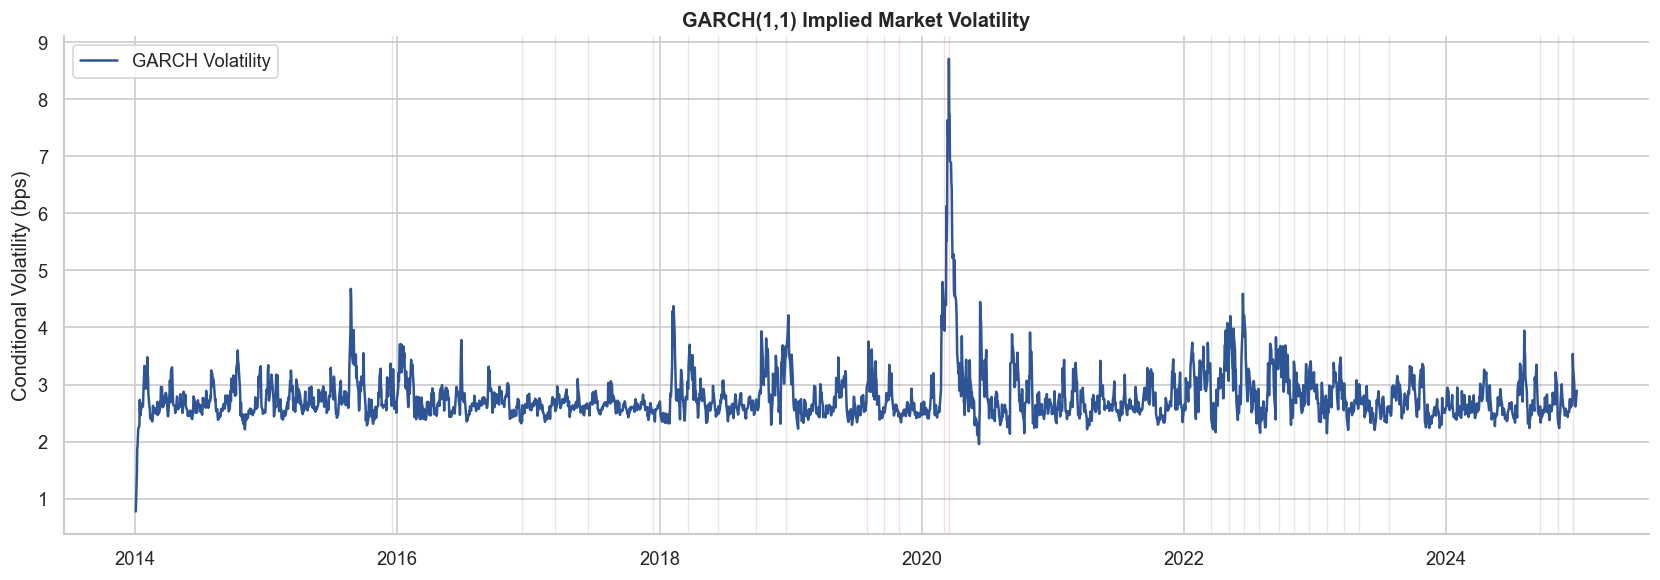

In [392]:
import matplotlib.pyplot as plt

garch_df['cond_vol_pct'] = res_hc.conditional_volatility
garch_df['cond_vol_bps'] = garch_df['cond_vol_pct'] * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(garch_df['Date'], garch_df['cond_vol_bps'], label='GARCH Volatility', color="#2F5597", linewidth=1.5)
for _, ev in events.iterrows():
    color = event_colors.get(ev.get('event_type'), '#C62828')
    ax.axvline(ev['Date'], color=color, alpha=0.15, linewidth=0.8)

ax.set_ylabel('Conditional Volatility (bps)')
ax.set_title('GARCH(1,1) Implied Market Volatility', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()




<div style="background:#eef8ef; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:6px; margin:10px 0;">
<b>GARCH takeaway:</b> The market GARCH model shows strong volatility persistence, with alpha + beta around 0.97 after correcting the duplicated-return issue. This supports using a volatility model, but the current hike/cut variables are in the mean equation rather than the variance equation, so GARCH should be framed as context rather than the strongest causal volatility test.
</div>

In [393]:
import pandas as pd

# 1) Equal-weighted sector return per day
sector_ret = (
    final_df
    .groupby(['Date', 'sector'])['ret']
    .mean()
    .reset_index()
)

# 2) Get one row per date for FOMC variables
fomc_daily = (
    final_df[['Date', 'is_hike', 'is_cut', 'change_bps']]
    .drop_duplicates(subset='Date')
    .sort_values('Date')
)

# 3) Merge FOMC info onto sector returns
sector_ret = (
    sector_ret
    .merge(fomc_daily, on='Date', how='left')
    .sort_values(['sector', 'Date'])
)
from arch import arch_model
import numpy as np

garch_sector_results = []

for sector, g in sector_ret.groupby('sector'):
    # Drop missing values
    g = g.dropna(subset=['ret', 'is_hike', 'is_cut', 'change_bps'])
    if g.empty:
        continue

    # Return series in %
    y = g['ret'].astype(float) * 100

    # Exogenous regressors in the mean equation
    X = g[['is_hike', 'is_cut', 'change_bps']].astype(float)

    # GARCH(1,1) with ARX mean
    am = arch_model(
        y,
        x=X,
        mean='ARX',   # constant + exog
        lags=0,
        vol='GARCH',
        p=1, q=1,
        dist='normal'
    )

    res = am.fit(update_freq=20, disp='off')

    # Store key parameters
    params = res.params
    alpha = params.get('alpha[1]', np.nan)
    beta  = params.get('beta[1]',  np.nan)

    garch_sector_results.append({
        'sector': sector,
        'omega': params.get('omega', np.nan),
        'alpha': alpha,
        'beta': beta,
        'alpha_plus_beta': alpha + beta if np.isfinite(alpha) and np.isfinite(beta) else np.nan,
        'beta_hike': params.get('is_hike', np.nan),
        'beta_cut': params.get('is_cut', np.nan),
        'beta_change_bps': params.get('change_bps', np.nan)
    })

garch_sector_df = pd.DataFrame(garch_sector_results)


In [394]:
garch_sector_df

,sector,omega,alpha,beta,alpha_plus_beta,beta_hike,beta_cut,beta_change_bps
0,Communication Services,0.040377,0.098105,0.876479,0.974584,1.308585,-1.385568,-0.043219
1,Consumer Cyclical,0.044625,0.115182,0.857832,0.973014,0.156131,-0.507341,-0.020364
2,Finance,0.099380,0.159980,0.791095,0.951075,-0.046152,-0.789731,-0.024895
3,Healthcare,0.039162,0.108686,0.854602,0.963288,-0.649329,0.343687,0.004955
4,Technology,0.107828,0.125635,0.833237,0.958872,1.049285,-1.250769,-0.042318
5,Utility,0.039174,0.078162,0.887796,0.965958,-0.788905,1.300840,0.027153


In [395]:
from arch import arch_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1) Sector-level equal-weighted returns
sector_ret = (
    final_df
    .groupby(['Date', 'sector'])['ret']
    .mean()
    .reset_index()
)

# 2) One row per date for FOMC variables
fomc_daily = (
    final_df[['Date', 'is_hike', 'is_cut', 'change_bps']]
    .drop_duplicates(subset='Date')
    .sort_values('Date')
)

# 3) Merge FOMC info onto sector returns
sector_ret = (
    sector_ret
    .merge(fomc_daily, on='Date', how='left')
    .sort_values(['sector', 'Date'])
)

# Make sure events['Date'] is datetime and event_type is clean
events_plot = events.copy()
events_plot['Date'] = pd.to_datetime(events_plot['Date'])
events_plot['event_type'] = events_plot['event_type'].str.lower()

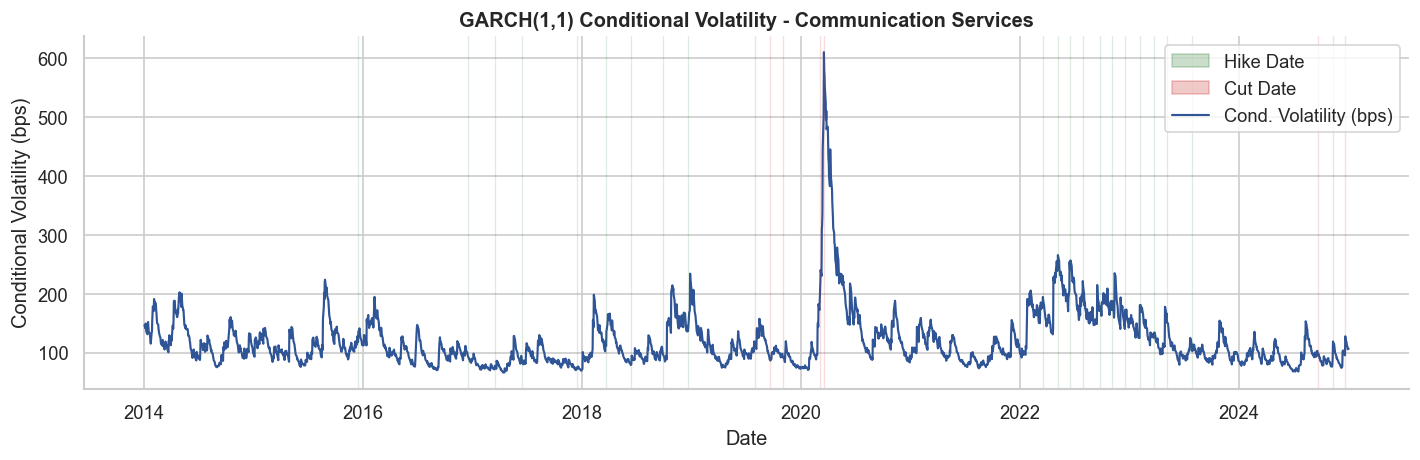

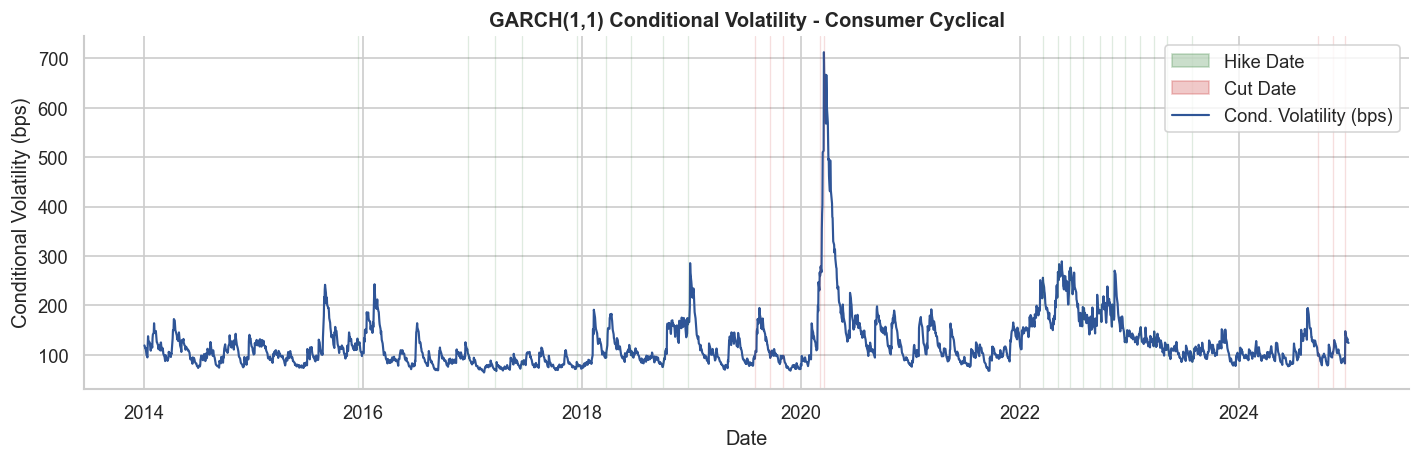

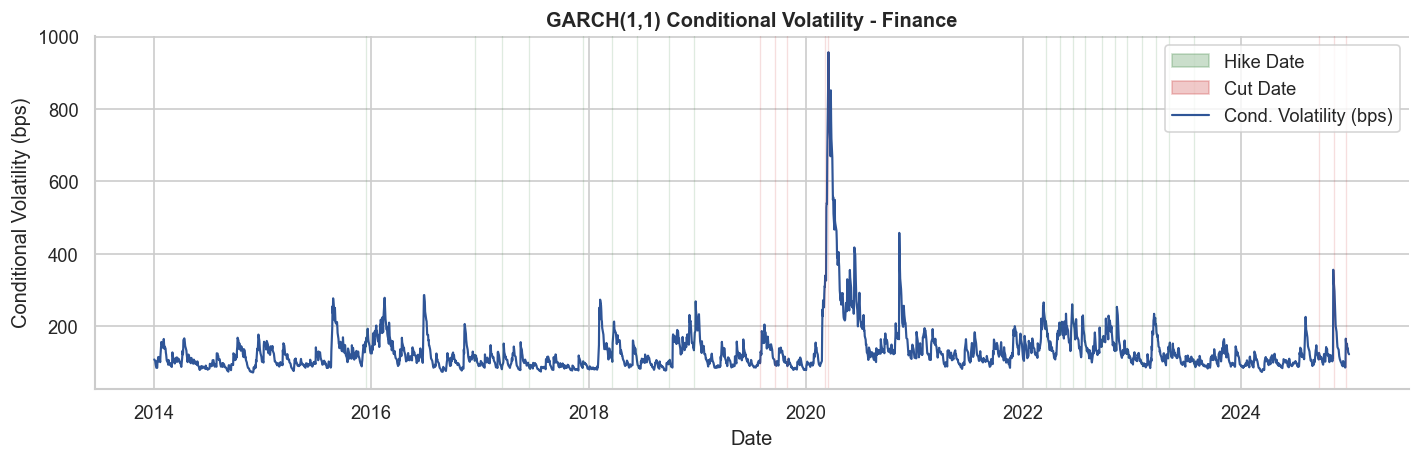

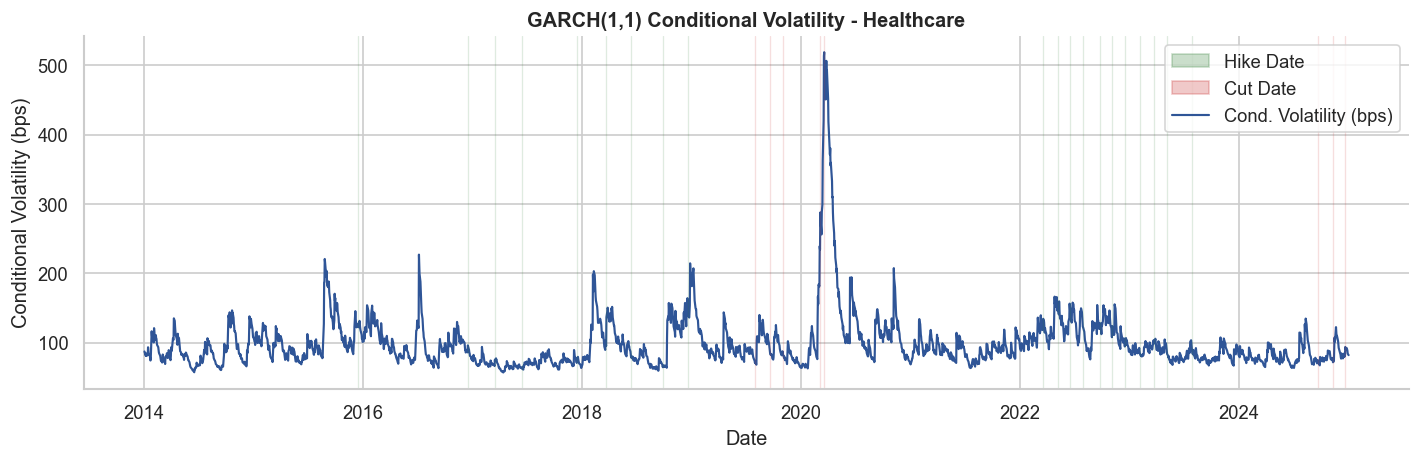

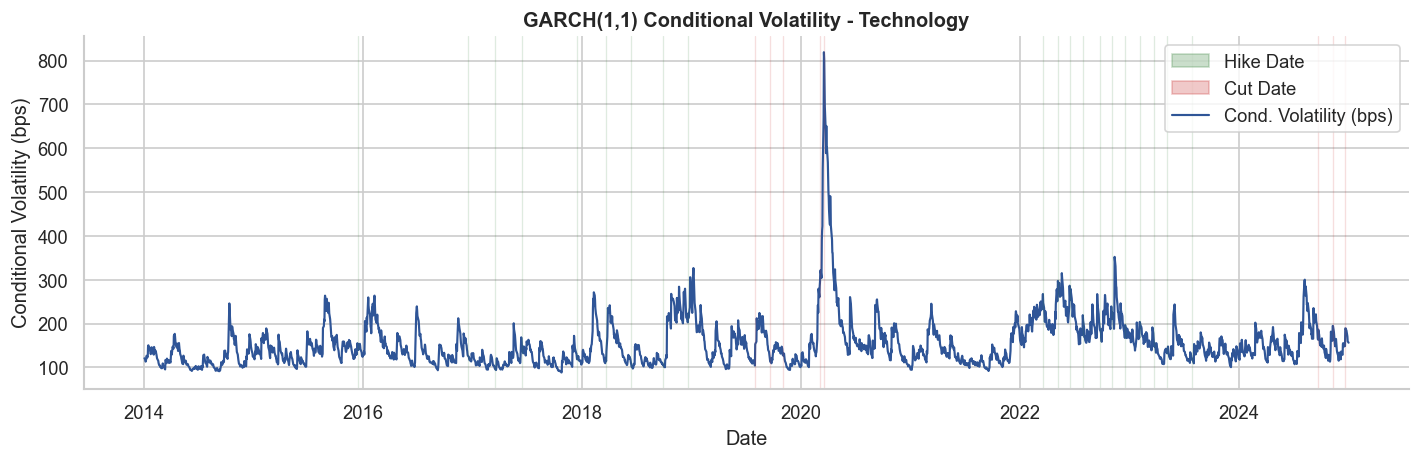

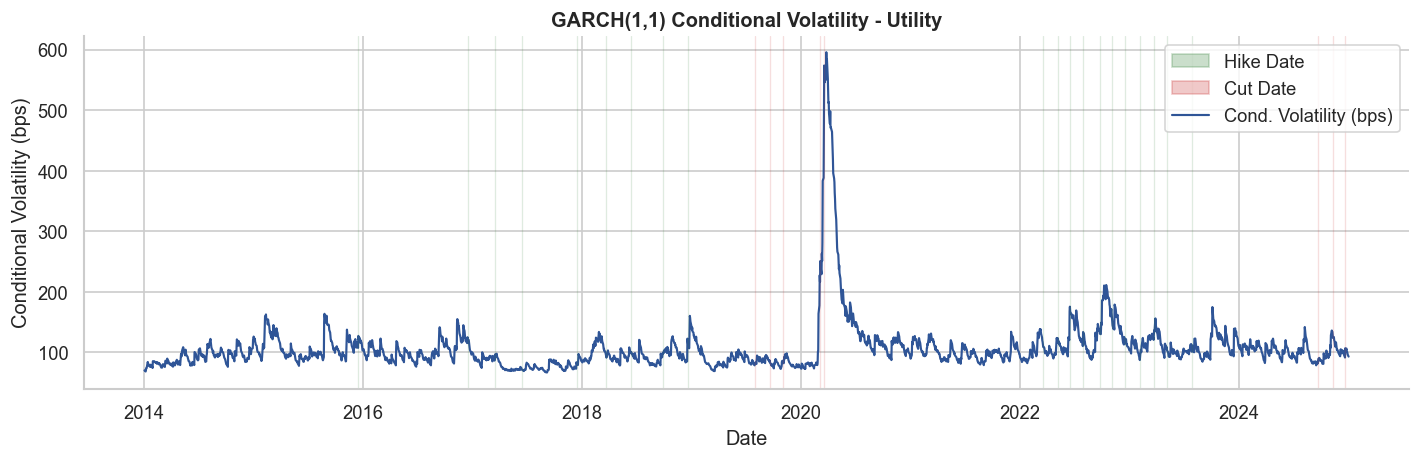

In [396]:
for sector, g in sector_ret.groupby('sector'):
    # drop only rows without returns
    g = g.dropna(subset=['ret'])
    if g.empty:
        continue

    y = g['ret'].astype(float) * 100
    X = g[['is_hike', 'is_cut']].astype(float)

    am = arch_model(
        y,
        x=X,
        mean='ARX',
        lags=0,
        vol='GARCH',
        p=1, q=1,
        dist='normal'
    )
    res = am.fit(update_freq=20, disp='off')

    g = g.copy()
    g['cond_vol_pct'] = res.conditional_volatility
    g['cond_vol_bps'] = g['cond_vol_pct'] * 100

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(g['Date'], g['cond_vol_bps'], label='Cond. Volatility (bps)', color="#2F5597", linewidth=1.3)
        # Add FOMC vertical lines: green=hike, red=cut
    start, end = g['Date'].min(), g['Date'].max()
    for _, ev in events_plot.iterrows():
        dt = ev['Date']
        if dt < start or dt > end:
            continue
        color = event_colors.get(ev['event_type'], '#C62828')
        ax.axvline(dt, color=color, alpha=0.15, linewidth=0.8)

    # Legend entries for hikes/cuts
    legend_handles = [
        Patch(color=event_colors['hike'], alpha=0.25, label='Hike Date'),
        Patch(color=event_colors['cut'],   alpha=0.25, label='Cut Date')
    ]

    ax.set_title(f"GARCH(1,1) Conditional Volatility - {sector}", fontweight='bold')
    ax.set_ylabel("Conditional Volatility (bps)")
    ax.set_xlabel("Date")
    ax.legend(handles=legend_handles + [ax.lines[0]], loc='upper right')

    plt.tight_layout()
    plt.show()


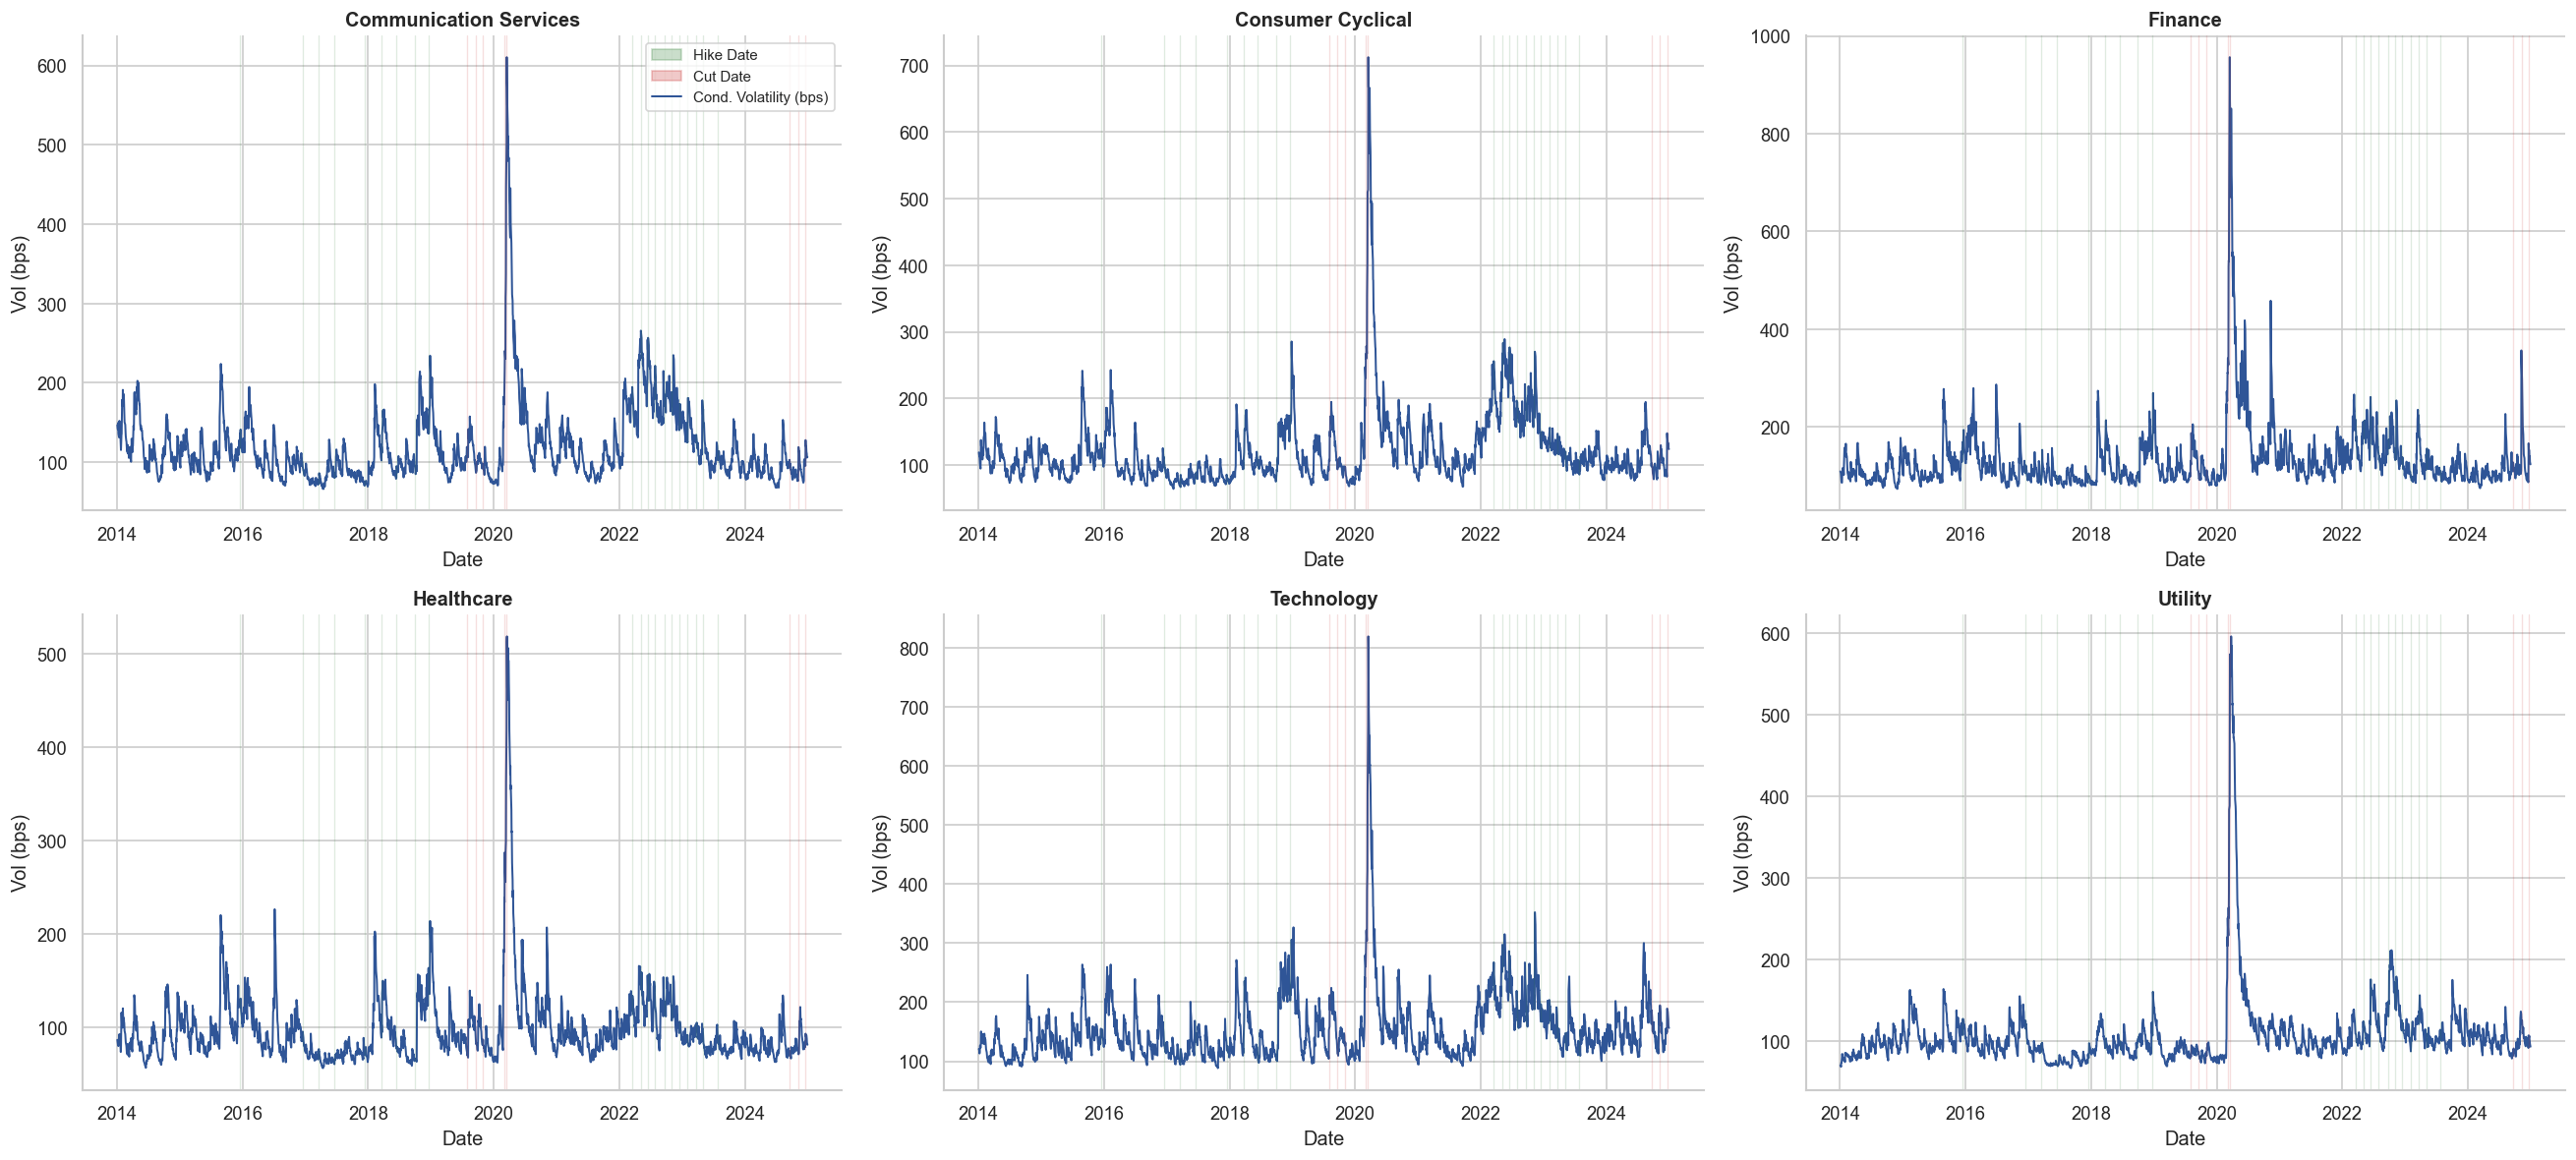

In [397]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from arch import arch_model

# Identify unique sectors
unique_sectors = sector_ret['sector'].dropna().unique()

fig, axes = plt.subplots(2, 3, figsize=(22, 10), sharex=False)
axes = axes.flatten()

legend_handles = [
    Patch(color=event_colors['hike'], alpha=0.25, label='Hike Date'),
    Patch(color=event_colors['cut'],   alpha=0.25, label='Cut Date')
]

for i, sector in enumerate(unique_sectors):
    if i >= 6:
        break  # Only plot first 6 sectors for a 2×3 grid

    ax = axes[i]

    # Filter and clean data
    g = sector_ret[sector_ret['sector'] == sector].dropna(subset=['ret'])
    if g.empty:
        ax.set_visible(False)
        continue

    y = g['ret'].astype(float) * 100
    X = g[['is_hike', 'is_cut']].astype(float)

    # Fit GARCH(1,1)
    am = arch_model(y, x=X, mean='ARX', lags=0,
                    vol='GARCH', p=1, q=1, dist='normal')
    res = am.fit(update_freq=20, disp='off')

    # Save conditional volatility
    g = g.copy()
    g['cond_vol_pct'] = res.conditional_volatility
    g['cond_vol_bps'] = g['cond_vol_pct'] * 100

    # Plot conditional volatility
    ax.plot(g['Date'], g['cond_vol_bps'], label='Cond. Volatility (bps)', color="#2F5597", linewidth=1.2)

    # Add event vertical lines
    start, end = g['Date'].min(), g['Date'].max()
    for _, ev in events_plot.iterrows():
        dt = ev['Date']
        if start <= dt <= end:
            color = event_colors.get(ev['event_type'], '#C62828')
            ax.axvline(dt, color=color, alpha=0.15, linewidth=0.8)

    # Titles / labels
    ax.set_title(f"{sector}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Vol (bps)")
    ax.set_xlabel("Date")

    # Add legend inside grid only once
    if i == 0:
        ax.legend(handles=legend_handles + [ax.lines[0]],
                  loc='upper right', fontsize=9)

# Turn off unused subplots (if < 6 sectors)
for j in range(i+1, 6):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


/var/folders/fj/pxz8d_45589622lsp3n_9t4h0000gn/T/ipykernel_62639/3426003790.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


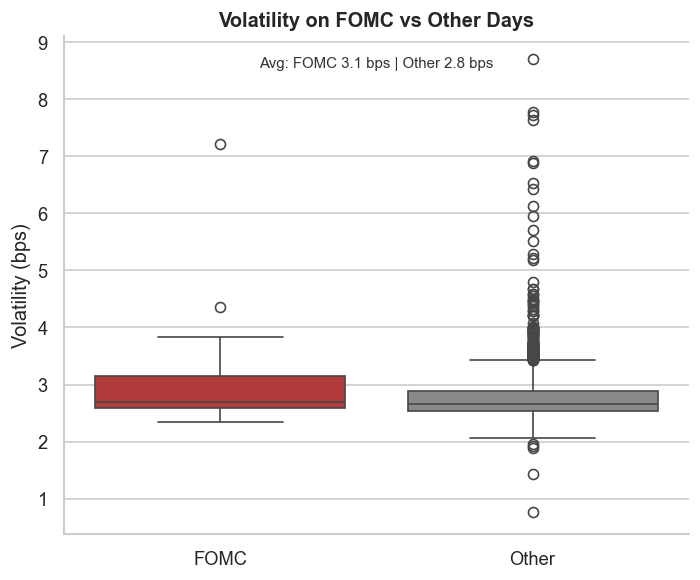

In [398]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fomc_vol = garch_df.loc[garch_df['is_hike'] + garch_df['is_cut'] > 0, 'cond_vol_bps']
other_vol = garch_df.loc[garch_df['is_hike'] + garch_df['is_cut'] == 0, 'cond_vol_bps']

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data=pd.DataFrame({
        'Volatility (bps)': pd.concat([fomc_vol, other_vol], ignore_index=True),
        'Day Type': ['FOMC'] * len(fomc_vol) + ['Other'] * len(other_vol)
    }),
    x='Day Type',
    y='Volatility (bps)',
    palette={'FOMC': '#C62828', 'Other': '#8A8A8A'},
    ax=ax
)
ax.set_xlabel("")
ax.set_title("Volatility on FOMC vs Other Days", fontweight='bold')
ax.text(
    0.5,
    0.96,
    f"Avg: FOMC {fomc_vol.mean():.1f} bps | Other {other_vol.mean():.1f} bps",
    transform=ax.transAxes,
    ha='center',
    va='top',
    fontsize=9,
    color='#333333'
)
plt.tight_layout()
plt.show()


## Model 5: Panel Fixed Effects Regression

Use stock fixed effects to compare FOMC-day return effects within the same stock over time, controlling for permanent stock-level differences.

In [399]:
from linearmodels.panel import PanelOLS
import pandas as pd

df = final_df.copy()

# ensure sorted
df = df.sort_values(['ticker', 'Date'])

# set panel index
df = df.set_index(['ticker', 'Date'])

mod = PanelOLS(
    df['ret'],
    df[['is_hike', 'is_cut', 'change_bps']],
    entity_effects=True   # stock FE
)

res = mod.fit(cov_type='clustered', cluster_entity=True)
print(res)


                          PanelOLS Estimation Summary                           
Dep. Variable:                    ret   R-squared:                        0.0036
Estimator:                   PanelOLS   R-squared (Between):             -0.1532
No. Observations:              165960   R-squared (Within):               0.0036
Date:                Sun, May 03 2026   R-squared (Overall):              0.0033
Time:                        16:24:05   Log-likelihood                 4.188e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      202.48
Entities:                          60   P-value                           0.0000
Avg Obs:                       2766.0   Distribution:                F(3,165897)
Min Obs:                       2766.0                                           
Max Obs:                       2766.0   F-statistic (robust):             97.221
                            

<div style="background:#f5f5f5; border-left:6px solid #555555; padding:12px 14px; border-radius:6px; margin:10px 0;">
<b>Modeling caveat:</b> The return and panel models show that FOMC days are associated with directional stock moves, but the volatility question is better supported by squared-return, event-window, and GARCH-style evidence. Because there are only 28 FOMC action dates, interpret these as associations rather than strict causal estimates.
</div>

- A rate hike day is associated with an average abnormal return of −2.09% for individual stocks, after controlling for all stock-specific characteristics.
- A rate cut day is associated with an average abnormal return of +0.73%.
- Each additional 1 bp increase in the policy rate is associated with +0.04% in stock returns.

## Final Takeaway: Big Picture Conclusion

<div style="background:#fff3e8; border:2px solid #c25a00; padding:16px 18px; border-radius:8px; margin:14px 0;">
<h3 style="margin-top:0; color:#8a3d00;">Big Picture Conclusion</h3>
<p><b>FOMC days are associated with noticeably higher stock volatility, especially rate cut days.</b> The cleanest evidence comes from the event-window volatility results: average daily volatility is about <b>192 bps</b> on non-event days, about <b>236 bps</b> on hike days, and about <b>544 bps</b> on cut days.</p>
<p>This suggests that the market treats FOMC action days as high-information, high-uncertainty moments. Rate cuts produce the largest volatility spike, which is consistent with cuts often occurring during stressed macro environments. Sector results also suggest that Utilities are more defensive, while Consumer Cyclical, Finance, Technology, and Communication Services show stronger event-day reactions.</p>
<p><b>Interview framing:</b> These results support an association between FOMC events and volatility, but I would avoid claiming strict causality because there are only 28 action dates and the events are tied to broader macro regimes.</p>
</div>

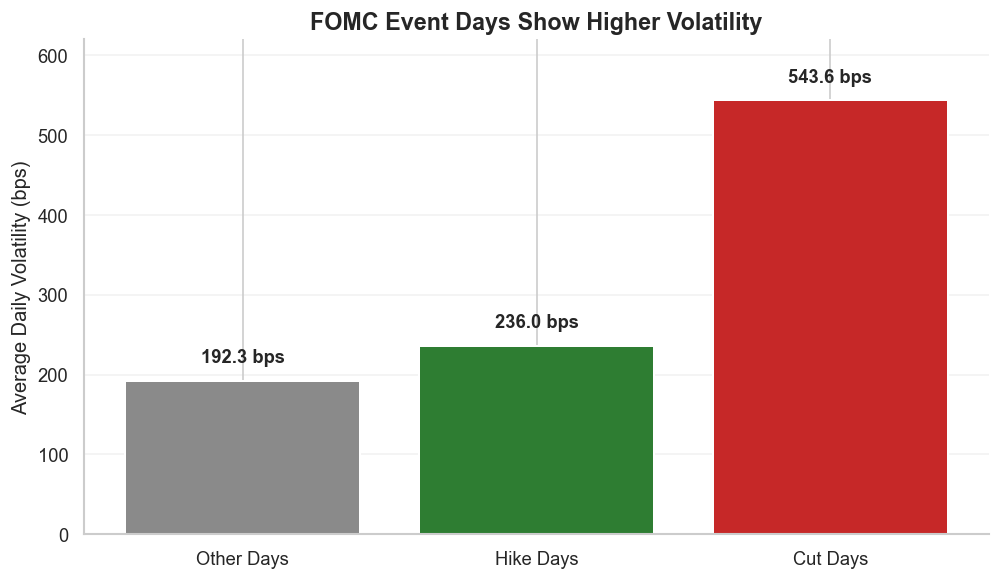

In [401]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

big_picture_vol = pd.DataFrame({
    'Day Type': ['Other Days', 'Hike Days', 'Cut Days'],
    'Average Volatility (bps)': [192.3, 236.0, 543.6],
    'Color': ['#8A8A8A', '#2E7D32', '#C62828']
})

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.bar(
    big_picture_vol['Day Type'],
    big_picture_vol['Average Volatility (bps)'],
    color=big_picture_vol['Color'],
    edgecolor="white",
    linewidth=1.2
)

ax.set_title("FOMC Event Days Show Higher Volatility", fontweight="bold", fontsize=14)
ax.set_ylabel("Average Daily Volatility (bps)")
ax.set_xlabel("")
ax.set_ylim(0, 620)
ax.grid(True, axis="y", alpha=0.25)

for bar, value in zip(bars, big_picture_vol["Average Volatility (bps)"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 18,
        f"{value:.1f} bps",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


plt.tight_layout()
plt.show()
